**Nikhil Sunder**  
ICSRI Research Fellow, University of Miami | Open-Source Developer  
Herbert Business School, University of Miami  
B.S.B.A. Quantitative Economics & Finance; Minor in Mathematics  

**Correspondence:** nss106@miami.edu | +1 (305) 409-3108  
**Research profiles:** [GitHub](https://github.com/nikhilxsunder) · [ORCID](https://orcid.org/0009-0007-3323-1760) · [LinkedIn](https://www.linkedin.com/in/nikhil-sunder/) · [Zenodo](https://zenodo.org/search?q=metadata.creators.person_or_org.name:%22Sunder,+Nikhil%22)  
**Software:** [PyPI](https://pypi.org/user/nikhil.sunder/) · [Anaconda](https://anaconda.org/nikhil.sunder/)  

# Linear Economy Estimation via a Restricted SVAR(2)

This notebook estimates a **linear reduced-form macroeconomic environment** using a **recursive (triangular) SVAR(2)** implemented through equation-by-equation OLS, followed by **post-estimation lag restriction** based on statistical significance. The resulting system is used as a compact forecasting and simulation environment for downstream policy-learning exercises (Sims, 1980; Lütkepohl, 2005).

## Reproducibility and runtime

All computations are executed in a Python virtual environment targeting **Python 3.13**. Results may differ across Python or package versions due to numerical and API-level changes. For replicability, record the full dependency set (e.g., `pip freeze`) alongside the notebook outputs (Python Software Foundation, 2025; Skipper & Josef, 2010).

# Baseline Specification (Bundesbank-aligned)

The baseline model follows the empirical spirit of the Bundesbank-adjacent reinforcement learning framework by first estimating a **parsimonious linear macroeconomic law of motion** and then using it as an environment for policy analysis (Hinterlang & Tänzer, 2021). The emphasis here is on a transparent, replicable linear benchmark rather than full structural identification.

## Software and libraries

The empirical pipeline relies on:  
- **Data access**: `fedfred` (a typed client for the FRED API) for retrieval and standardized conversion of FRED observation frames into `pandas.Series` via `FredHelpers.to_pd_series` (Sunder, 2025).
- **Data wrangling**: `pandas` for time-indexed manipulation and alignment (pandas development team, 2025).  
- **Numerical computing**: `NumPy` for vectorized operations and interoperability (Harris et al., 2020).  
- **Estimation and diagnostics**: `statsmodels` for OLS estimation and standard residual tests (Skipper & Josef, 2010).  
- **Visualization**: `matplotlib` for publication-oriented plotting (Hunter, 2007).

This combination is standard in applied macroeconometrics and supports transparent replication.

In [286]:
%pip install fedfred pandas numpy statsmodels matplotlib ipympl ipywidgets jupyterlab-lsp nbdime --quiet

Note: you may need to restart the kernel to use updated packages.


In [287]:
from typing import Dict, List, Any
from dataclasses import dataclass
from IPython.display import Markdown, display

import fedfred as fed
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
import matplotlib.pyplot as plt

In [288]:
%matplotlib widget

## Sample definition and modeling assumptions

### Sample window
The baseline training window is **1987Q3–2007Q2**, consistent with a pre-crisis estimation period commonly used to limit regime breaks associated with the Global Financial Crisis. The out-of-sample window begins in **2007Q3** and extends to the most recent available observation.

### Frequency and aggregation
All series are used at **quarterly frequency**. When a series is available at higher frequency (e.g., the effective federal funds rate), values are aggregated to quarters using appropriate summary statistics (here: quarterly averages), which is standard when mapping daily rates into quarterly policy indicators (Federal Reserve Bank of St. Louis, n.d.).

### Linear benchmark
The estimated environment is intentionally linear and low-dimensional to serve as a tractable benchmark for later policy-learning comparisons (Hinterlang & Tänzer, 2021; Lütkepohl, 2005).

In [289]:
# Training data Time Period: Q3 1987 - Q2 2007
start_date = "1987-07-01"
end_date = "2007-06-30"

# Training data Observation Frequency
freq = "q"  # Quarterly

# Fred client
fred = fed.FredAPI(api_key="7ab121fb17773e187bb6508e83e411da", cache_mode=True, cache_size=256)

## Data utilities

### Standardizing FRED response frames
`fedfred` returns series observations in a consistent **tabular response format** (typically a `pandas.DataFrame` containing `date` and `value`). To ensure uniform downstream handling (merging, lag construction, and design-matrix formation), we convert each response into a **float-valued `pandas.Series` with a `DatetimeIndex`** using `fedfred`’s built-in helper `FredHelpers.to_pd_series`. This removes custom parsing logic and reduces the risk of silent type/index inconsistencies (pandas development team, 2025; Sunder, 2025).

## Data retrieval and construction of observables

### Data source
All time series are downloaded from the **Federal Reserve Economic Data (FRED)** database (Federal Reserve Bank of St. Louis, n.d.). Series are retrieved at quarterly frequency with transformations applied at the API level where appropriate to reduce downstream transformation ambiguity.

### Observables
We construct three core observables:
- **Inflation (πₜ)**: year-over-year percent change in the GDP implicit price deflator (FRED series: `GDPDEF`).  
- **Output gap (yₜ)**: percent deviation of real output from potential output, computed from real GDP and potential GDP (FRED series: `GDPC1`, `GDPPOT`).  
- **Policy rate (iₜ)**: quarterly average of the effective federal funds rate (FRED series: `FEDFUNDS`).

These choices mirror standard applied macro benchmarks and align with the baseline specification used for environment estimation (Hinterlang & Tänzer, 2021; Lütkepohl, 2005).

In [290]:
# Fetch data from FRED
gdpdef_yoy = fred.get_series_observations(
    series_id="GDPDEF",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    units="pc1" # YoY percent change
)

real_gdp = fred.get_series_observations(
    series_id="GDPC1",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    units="lin" # Linear units (level)
)

potential_gdp = fred.get_series_observations(
    series_id="GDPPOT",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    units="lin" # Linear units (level)
)

effective_ffr = fred.get_series_observations(
    series_id="FEDFUNDS",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    aggregation_method="avg" # Aggregate daily data to quarterly by averaging (specificly important for interest rates)
)

# Check data
print(gdpdef_yoy.head())
print(real_gdp.head())
print(potential_gdp.head())
print(effective_ffr.head())

           realtime_start realtime_end    value
date                                           
1987-07-01     2026-02-20   2026-02-20  2.66122
1987-10-01     2026-02-20   2026-02-20  2.91876
1988-01-01     2026-02-20   2026-02-20  3.06577
1988-04-01     2026-02-20   2026-02-20  3.35274
1988-07-01     2026-02-20   2026-02-20  3.80207
           realtime_start realtime_end     value
date                                            
1987-07-01     2026-02-20   2026-02-20  9162.024
1987-10-01     2026-02-20   2026-02-20  9319.332
1988-01-01     2026-02-20   2026-02-20  9367.502
1988-04-01     2026-02-20   2026-02-20  9490.594
1988-07-01     2026-02-20   2026-02-20  9546.206
           realtime_start realtime_end        value
date                                               
1987-07-01     2026-03-02   2026-03-02  9191.505940
1987-10-01     2026-03-02   2026-03-02  9262.554077
1988-01-01     2026-03-02   2026-03-02  9332.898162
1988-04-01     2026-03-02   2026-03-02  9402.936119
1988-07-0

### Series construction (library-standardized)
Each downloaded FRED response is converted to a `pandas.Series` using `fed.FredHelpers.to_pd_series`, then renamed to match the model notation. This keeps the pipeline consistent across series and avoids ad-hoc DataFrame parsing.

In [291]:
# Convert to Series with proper names
pi = fed.FredHelpers.to_pd_series(gdpdef_yoy, "pi")
y_real = fed.FredHelpers.to_pd_series(real_gdp, "y_real")
y_pot = fed.FredHelpers.to_pd_series(potential_gdp, "y_pot")
i = fed.FredHelpers.to_pd_series(effective_ffr, "i")

# Check converted data
print(pi.head())
print(y_real.head())
print(y_pot.head())
print(i.head())

date
1987-07-01    2.66122
1987-10-01    2.91876
1988-01-01    3.06577
1988-04-01    3.35274
1988-07-01    3.80207
Name: pi, dtype: float64
date
1987-07-01    9162.024
1987-10-01    9319.332
1988-01-01    9367.502
1988-04-01    9490.594
1988-07-01    9546.206
Name: y_real, dtype: float64
date
1987-07-01    9191.505940
1987-10-01    9262.554077
1988-01-01    9332.898162
1988-04-01    9402.936119
1988-07-01    9472.372905
Name: y_pot, dtype: float64
date
1987-07-01    6.84
1987-10-01    6.92
1988-01-01    6.66
1988-04-01    7.16
1988-07-01    7.98
Name: i, dtype: float64


### Inflation definition and transformation
Inflation is measured as **year-over-year percent change**: 

$$
{\pi_t = 100 \times \left(\frac{P_t}{P_{t-4}} - 1\right)}
$$. 

The notebook requests this transformation directly from FRED (via units corresponding to YoY percent change), which reduces implementation variance and makes the transformation explicit at the data-source layer (Federal Reserve Bank of St. Louis, n.d.).

In [292]:
# Double check var assignment
print(pi.head())
print(pi.tail())

date
1987-07-01    2.66122
1987-10-01    2.91876
1988-01-01    3.06577
1988-04-01    3.35274
1988-07-01    3.80207
Name: pi, dtype: float64
date
2006-04-01    3.35642
2006-07-01    3.13805
2006-10-01    2.66316
2007-01-01    2.91019
2007-04-01    2.72883
Name: pi, dtype: float64


### Output gap construction
The output gap is defined as the percent deviation of real output from potential output:

$$
{y_t = 100 \times \left(\frac{Y_t}{Y_t^\ast} - 1\right).}
$$

This ratio-based measure is scale-free and directly interpretable in percentage points, which is convenient for both regression interpretation and policy simulation (Lütkepohl, 2005).

In [293]:
y_gap = 100.0 * (y_real / y_pot - 1.0)
y_gap.name = "y"

# Check calculated series
print(y_gap.head())
print(y_gap.tail())

date
1987-07-01   -0.320752
1987-10-01    0.612983
1988-01-01    0.370773
1988-04-01    0.932239
1988-07-01    0.779457
Name: y, dtype: float64
date
2006-04-01    1.316103
2006-07-01    0.921755
2006-10-01    1.268135
2007-01-01    1.053059
2007-04-01    1.151432
Name: y, dtype: float64


### Policy indicator
The policy rate ${i_t}$ is measured using the **effective federal funds rate**, aggregated to quarterly frequency by averaging within each quarter to align timing with the quarterly macro series (Federal Reserve Bank of St. Louis, n.d.).

In [294]:
# Double check var assignment
print(i.head())
print(i.tail())

date
1987-07-01    6.84
1987-10-01    6.92
1988-01-01    6.66
1988-04-01    7.16
1988-07-01    7.98
Name: i, dtype: float64
date
2006-04-01    4.91
2006-07-01    5.25
2006-10-01    5.25
2007-01-01    5.26
2007-04-01    5.25
Name: i, dtype: float64


### Alignment and integrity checks
The observables are merged into a single quarterly dataset and checked for:
- consistent quarterly indexing,
- expected sample bounds,
- absence of missing values after alignment.

These checks help ensure that subsequent lag construction and OLS estimation are not contaminated by silent misalignment (pandas development team, 2025).

In [295]:
# Merge
df = pd.concat([pi, y_gap, i], axis=1).dropna()
df.index = pd.PeriodIndex(df.index, freq="Q") # Use a quarterly PeriodIndex

# Check
print(df.head())
print(df.tail())
print(df.index.min(), "→", df.index.max())

# Additional Sanity Check:
assert df.index.min() == pd.Period("1987Q3", "Q")
assert df.index.max() == pd.Period("2007Q2", "Q")
assert len(df) == 80
assert not df.isna().any().any()

             pi         y     i
date                           
1987Q3  2.66122 -0.320752  6.84
1987Q4  2.91876  0.612983  6.92
1988Q1  3.06577  0.370773  6.66
1988Q2  3.35274  0.932239  7.16
1988Q3  3.80207  0.779457  7.98
             pi         y     i
date                           
2006Q2  3.35642  1.316103  4.91
2006Q3  3.13805  0.921755  5.25
2006Q4  2.66316  1.268135  5.25
2007Q1  2.91019  1.053059  5.26
2007Q2  2.72883  1.151432  5.25
1987Q3 → 2007Q2


## Estimating the linear environment (restricted recursive SVAR(2))

We estimate a **recursive reduced-form SVAR(2)** using equation-by-equation OLS. The recursive structure is implemented by allowing inflation to depend contemporaneously on the output gap (triangular ordering), which corresponds to a standard Cholesky-style identification in VAR applications (Sims, 1980; Lütkepohl, 2005).

### Estimation outputs
For transparency and reproducibility, the estimation routine returns:
- fitted OLS objects (full and restricted),
- regression design matrices used for prediction,
- residual series for diagnostics,
- coefficient and p-value tables that remain index-stable even after restrictions.

This design supports clean table construction and avoids downstream errors when terms are excluded during restriction.

In [296]:
@dataclass(frozen=True)
class _ResultsView:
    """
    Wrapper for a *restricted/refit* statsmodels result that:
    - delegates diagnostics/predict/summary to the restricted refit
    - exposes `.params`/`.pvalues` as "table-safe" Series that also include dropped terms
      (dropped terms show coef=0.0; pvalue is taken from the full model used for the drop decision)
    """
    _res_restricted: sm.regression.linear_model.RegressionResultsWrapper
    _params_table: pd.Series
    _pvalues_table: pd.Series

    @property
    def params(self) -> pd.Series:
        return self._params_table

    @property
    def pvalues(self) -> pd.Series:
        return self._pvalues_table

    def __getattr__(self, name):
        return getattr(self._res_restricted, name)


@dataclass(frozen=True)
class SVARResults:
    _mod_y_full: sm.regression.linear_model.RegressionResultsWrapper
    _mod_pi_full: sm.regression.linear_model.RegressionResultsWrapper
    _mod_y_restricted: sm.regression.linear_model.RegressionResultsWrapper
    _mod_pi_restricted: sm.regression.linear_model.RegressionResultsWrapper

    X_y: pd.DataFrame # restricted design matrix (used for predict)
    X_pi: pd.DataFrame # restricted design matrix (used for predict)
    resid_y: pd.Series
    resid_pi: pd.Series

    # table-safe (includes dropped terms as 0.0)
    coef_y: Dict[str, float]
    coef_pi: Dict[str, float]
    pvalues_y: Dict[str, float]
    pvalues_pi: Dict[str, float]

    zeroed_y: List[str] # dropped in refit
    zeroed_pi: List[str] # dropped in refit

    @property
    def mod_y(self) -> _ResultsView:
        return _ResultsView(
            self._mod_y_restricted,
            pd.Series(self.coef_y),
            pd.Series(self.pvalues_y),
        )

    @property
    def mod_pi(self) -> _ResultsView:
        return _ResultsView(
            self._mod_pi_restricted,
            pd.Series(self.coef_pi),
            pd.Series(self.pvalues_pi),
        )

        

### Restriction rule (post-estimation lag selection)
Following the baseline approach, the SVAR(2) is first estimated in full and then **restricted by removing statistically weak second-lag terms** using a significance threshold (default \(\alpha = 0.10\)). This yields a more parsimonious linear environment while retaining the SVAR(2) starting point as the reference specification (Hinterlang & Tänzer, 2021).

In [297]:
def identify_insignificant_lag2_terms(
    model: sm.regression.linear_model.RegressionResultsWrapper,
    *,
    alpha: float = 0.10,
    suffix: str = "_lag2",
) -> List[str]:
    """Return list of lag2 regressor names with p-value > alpha."""
    drop: List[str] = []
    for k in model.params.index:
        if k.endswith(suffix) and k in model.pvalues.index and float(model.pvalues[k]) > alpha:
            drop.append(k)
    return drop

### Estimation procedure

Let the state vector contain the output gap \(y_t\), inflation \(\pi_t\), and policy rate \(i_t\). The linear environment is estimated as a pair of reduced-form equations with up to two lags.

1. **Output-gap equation (no contemporaneous regressors)**  
$$
y_t = C^y + \alpha^{y\prime} s_t^y + \varepsilon_t^y, \quad
s_t^y = (y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2}).
$$

2. **Inflation equation (recursive ordering allows contemporaneous \(y_t\))**  
$$
\pi_t = C^\pi + \alpha^{\pi\prime} s_t^\pi + \varepsilon_t^\pi, \quad
s_t^\pi = (y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2}).
$$

Both equations are first estimated via OLS, and the model is then **restricted** by dropping insignificant second-lag regressors based on the full-model p-values. This is a pragmatic, transparent approach to obtain a compact environment suitable for simulation and comparison (Sims, 1980; Hinterlang & Tänzer, 2021; Lütkepohl, 2005).

In [298]:
def fit_linear_svar(df: pd.DataFrame, alpha_drop: float = 0.10) -> SVARResults:
    """
    Paper-aligned procedure:
    1) fit full SVAR(2) OLS
    2) drop insignificant *_lag2 terms (p > alpha_drop) based on the full fit
    3) refit the restricted model without those regressors
    """
    assert {"pi", "y", "i"}.issubset(df.columns), "df must have columns: 'pi', 'y', 'i'"

    work = df.copy().sort_index()
    for c in ("pi", "y", "i"):
        work[f"{c}_lag1"] = work[c].shift(1)
        work[f"{c}_lag2"] = work[c].shift(2)

    # ---- y equation (FULL) ----
    y_target = work["y"]
    X_y_full = work[["y_lag1", "y_lag2", "pi_lag1", "pi_lag2", "i_lag1", "i_lag2"]]
    X_y_full = sm.add_constant(X_y_full, has_constant="add")
    ymask = X_y_full.notna().all(axis=1) & y_target.notna()
    X_y_full = X_y_full.loc[ymask]
    y_target = y_target.loc[ymask]

    mod_y_full = sm.OLS(y_target, X_y_full).fit()
    drop_y = identify_insignificant_lag2_terms(mod_y_full, alpha=alpha_drop)

    # ---- y equation (RESTRICTED refit) ----
    X_y_res = X_y_full.drop(columns=drop_y, errors="ignore")
    mod_y_res = sm.OLS(y_target, X_y_res).fit()

    # ---- pi equation (FULL) ----
    pi_target = work["pi"]
    X_pi_full = work[["y", "y_lag1", "y_lag2", "pi_lag1", "pi_lag2", "i_lag1", "i_lag2"]]
    X_pi_full = sm.add_constant(X_pi_full, has_constant="add")
    pimask = X_pi_full.notna().all(axis=1) & pi_target.notna()
    X_pi_full = X_pi_full.loc[pimask]
    pi_target = pi_target.loc[pimask]

    mod_pi_full = sm.OLS(pi_target, X_pi_full).fit()
    drop_pi = identify_insignificant_lag2_terms(mod_pi_full, alpha=alpha_drop)

    # ---- pi equation (RESTRICTED refit) ----
    X_pi_res = X_pi_full.drop(columns=drop_pi, errors="ignore")
    mod_pi_res = sm.OLS(pi_target, X_pi_res).fit()

    # Residuals from restricted refits
    resid_y = (y_target - mod_y_res.predict(X_y_res)).rename("eps_y")
    resid_pi = (pi_target - mod_pi_res.predict(X_pi_res)).rename("eps_pi")

    # ---- Build "table-safe" params/pvalues that still include dropped terms ----
    # (so your Table 9 indexing doesn't KeyError)
    keys_y = list(X_y_full.columns)
    params_y_tbl = mod_y_res.params.reindex(keys_y, fill_value=0.0)
    pvals_y_tbl = mod_y_res.pvalues.reindex(keys_y)
    for k in drop_y:
        params_y_tbl.loc[k] = 0.0
        pvals_y_tbl.loc[k] = float(mod_y_full.pvalues.get(k, np.nan))

    keys_pi = list(X_pi_full.columns)
    params_pi_tbl = mod_pi_res.params.reindex(keys_pi, fill_value=0.0)
    pvals_pi_tbl = mod_pi_res.pvalues.reindex(keys_pi)
    for k in drop_pi:
        params_pi_tbl.loc[k] = 0.0
        pvals_pi_tbl.loc[k] = float(mod_pi_full.pvalues.get(k, np.nan))

    return SVARResults(
        _mod_y_full=mod_y_full,
        _mod_pi_full=mod_pi_full,
        _mod_y_restricted=mod_y_res,
        _mod_pi_restricted=mod_pi_res,
        X_y=X_y_res,
        X_pi=X_pi_res,
        resid_y=resid_y,
        resid_pi=resid_pi,
        coef_y=params_y_tbl.to_dict(),
        coef_pi=params_pi_tbl.to_dict(),
        pvalues_y=pvals_y_tbl.to_dict(),
        pvalues_pi=pvals_pi_tbl.to_dict(),
        zeroed_y=drop_y,
        zeroed_pi=drop_pi,
    )

In [299]:
# Fit SVAR
svar = fit_linear_svar(df)

print("\n=== Output gap equation ===")
print(svar.mod_y.summary())
print("\n=== Inflation equation ===")
print(svar.mod_pi.summary())

# Sanity Checks:
print("\nResidual std (y, pi):", svar.resid_y.std().round(3), svar.resid_pi.std().round(3))
print("Samples used (y, pi):", svar.mod_y.nobs, svar.mod_pi.nobs)


=== Output gap equation ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     157.1
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           5.23e-32
Time:                        17:27:09   Log-Likelihood:                -51.595
No. Observations:                  78   AIC:                             111.2
Df Residuals:                      74   BIC:                             120.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3070  

In [300]:
# sanity check: recursive lag zero
for k, v in svar.mod_y.params.items():
    print(k, v)

for k, v in svar.mod_pi.params.items():
    print(k, v)

for k,v in svar.mod_y.pvalues.items():
    print(k, v)

for k,v in svar.mod_pi.pvalues.items():
    print(k, v)

print("Zeroed in y eq:", svar.zeroed_y)
print("Zeroed in pi eq:", svar.zeroed_pi)

const 0.30699663695750923
y_lag1 0.977454375525983
y_lag2 0.0
pi_lag1 -0.02284855887129962
pi_lag2 0.0
i_lag1 -0.04986995556823324
i_lag2 0.0
const 0.12748387727986485
y -0.06418357939693214
y_lag1 0.2086345985948358
y_lag2 -0.10935513650816703
pi_lag1 1.291417099520853
pi_lag2 -0.3149531608741565
i_lag1 -0.01686060045876918
i_lag2 0.0
const 0.10110053602850734
y_lag1 3.683434705549112e-29
y_lag2 0.4509506274485227
pi_lag1 0.7786595543558107
pi_lag2 0.7173562612395243
i_lag1 0.1684990408831646
i_lag2 0.13078244880029452
const 0.091565781461768
y 0.159471541572887
y_lag1 0.002236824667005508
y_lag2 0.02303618961642713
pi_lag1 4.1143685833362264e-19
pi_lag2 0.005200802841283854
i_lag1 0.2732351940062221
i_lag2 0.23954155196401034
Zeroed in y eq: ['y_lag2', 'pi_lag2', 'i_lag2']
Zeroed in pi eq: ['i_lag2']


### Restricted reduced-form representation

After applying the lag restriction rule, the environment can be written as:
- a restricted output-gap equation with a subset of lag terms retained, and
- a restricted inflation equation that may include contemporaneous ${y_t}$ under the recursive ordering.

This representation is interpreted as a **reduced-form forecasting system**, not a fully structural causal model (Sims, 1980; Lütkepohl, 2005).

### Linear environment mapping
The restricted SVAR defines a mapping from observed state variables and lags to one-step-ahead fitted values:
$$
\hat f^m(s_t^m) = C^m + \alpha^{m\prime}s_t^m,\quad m\in\{\pi,y\}.
$$
This serves as the notebook’s **linear economy environment** used for in-sample diagnostics and out-of-sample comparison (Hinterlang & Tänzer, 2021).

### Substituted System

In [301]:
# Output Gap Components
const_str_y = {
    "string": f"{svar.mod_y.params['const']:.4f}", 
    "val": svar.mod_y.params['const']
    }

y_t1_str_y = {
    "string": f"{svar.mod_y.params['y_lag1']:.4f}y_{{t-1}}",
    "val": svar.mod_y.params['y_lag1']
    }

y_t2_str_y = {
    "string": f"{svar.mod_y.params['y_lag2']:.4f}y_{{t-2}}",
    "val": svar.mod_y.params['y_lag2']
    }

pi_t1_str_y = {
    "string": f"{svar.mod_y.params['pi_lag1']:.4f}{{\pi}}_{{t-1}}",
    "val": svar.mod_y.params['pi_lag1']
    }

pi_t2_str_y = {
    "string": f"{svar.mod_y.params['pi_lag2']:.4f}{{\pi}}_{{t-2}}",
    "val": svar.mod_y.params['pi_lag2']
    }

i_t1_str_y = {
    "string": f"{svar.mod_y.params['i_lag1']:.4f}i_{{t-1}}",
    "val": svar.mod_y.params['i_lag1']
    }

i_t2_str_y = {
    "string": f"{svar.mod_y.params['i_lag2']:.4f}i_{{t-2}}",
    "val": svar.mod_y.params['i_lag2']
    }

# Inflation Components
const_str_pi = {
    "string": f"{svar.mod_pi.params['const']:.4f}",
    "val": svar.mod_pi.params['const']
    }

y_t0_str_pi = {
    "string": f"{svar.mod_pi.params['y']:.4f}y_t",
    "val": svar.mod_pi.params['y']
    }

y_t1_str_pi = {
    "string": f"{svar.mod_pi.params['y_lag1']:.4f}y_{{t-1}}",
    "val": svar.mod_pi.params['y_lag1']
    }

y_t2_str_pi = {
    "string": f"{svar.mod_pi.params['y_lag2']:.4f}y_{{t-2}}",
    "val": svar.mod_pi.params['y_lag2']
    }

pi_t1_str_pi = {
    "string": f"{svar.mod_pi.params['pi_lag1']:.4f}{{\pi}}_{{t-1}}",
    "val": svar.mod_pi.params['pi_lag1']
    }

pi_t2_str_pi = {
    "string": f"{svar.mod_pi.params['pi_lag2']:.4f}{{\pi}}_{{t-2}}",
    "val": svar.mod_pi.params['pi_lag2']
    }

i_t1_str_pi = {
    "string": f"{svar.mod_pi.params['i_lag1']:.4f}i_{{t-1}}",
    "val": svar.mod_pi.params['i_lag1']
    }

i_t2_str_pi = {
    "string": f"{svar.mod_pi.params['i_lag2']:.4f}i_{{t-2}}",
    "val": svar.mod_pi.params['i_lag2']
    }

# Component Lists
y_t_list = [
    const_str_y,
    y_t1_str_y,
    y_t2_str_y,
    pi_t1_str_y,
    pi_t2_str_y,
    i_t1_str_y,
    i_t2_str_y,
]

pi_t_list = [
    const_str_pi,
    y_t0_str_pi,
    y_t1_str_pi,
    y_t2_str_pi,
    pi_t1_str_pi,
    pi_t2_str_pi,
    i_t1_str_pi,
    i_t2_str_pi,
]

def y_t_eq_str(components: List[Dict[str, Any]]) -> str:
    yt_str = components[0]["string"]
    for x in components[1:]:
        if x["val"] != 0:
            if x["string"].startswith("-"):
                yt_str += " " + x["string"]
            else:
                yt_str += " + " + x["string"]
    eq_str = r"""$$y_t = """ + yt_str + r"""$$"""
    return eq_str

def pi_t_eq_str(components: List[Dict[str, Any]]) -> str:
    pi_str = components[0]["string"]
    for x in components[1:]:
        if x["val"] != 0:
            if x["string"].startswith("-"):
                pi_str += " " + x["string"]
            else:
                pi_str += " + " + x["string"]
    eq_str = r"""$$\pi_t = """ + pi_str + r"""$$"""
    return eq_str
            
    

display(Markdown(
    r"""The new equations with their coefficients are as follows:"""))
display(Markdown(y_t_eq_str(y_t_list)))
display(Markdown(pi_t_eq_str(pi_t_list)))

The new equations with their coefficients are as follows:

$$y_t = 0.3070 + 0.9775y_{t-1} -0.0228{\pi}_{t-1} -0.0499i_{t-1}$$

$$\pi_t = 0.1275 -0.0642y_t + 0.2086y_{t-1} -0.1094y_{t-2} + 1.2914{\pi}_{t-1} -0.3150{\pi}_{t-2} -0.0169i_{t-1}$$

### Table 9 — Restricted SVAR estimates and diagnostics (replication-style summary)

The table reports restricted OLS coefficients and associated p-values, together with standard residual diagnostics (e.g., Durbin–Watson and LM-style serial correlation tests). These statistics provide a compact assessment of fit and residual dependence for the linear benchmark (Skipper & Josef, 2010).

In [302]:
# Output Gap Equation Rows
coeff_row_str_y = {
    "string": f"| $C^y$ | {svar.mod_y.params['const']:.4f} | {svar.mod_y.pvalues['const']:.4f} |",
    "coeff": svar.mod_y.params["const"],
    "pvalue": svar.mod_y.pvalues["const"]
}

y_1_row_str_y = {
    "string": f"| $a^y_{{y,1}}$ | {svar.mod_y.params['y_lag1']:.4f} | {svar.mod_y.pvalues['y_lag1']:.4f} |",
    "coeff": svar.mod_y.params["y_lag1"],
    "pvalue": svar.mod_y.pvalues["y_lag1"]
}

y_2_row_str_y = {
    "string": f"| $a^y_{{y,2}}$ | {svar.mod_y.params['y_lag2']:.4f} | {svar.mod_y.pvalues['y_lag2']:.4f} |",
    "coeff": svar.mod_y.params["y_lag2"],
    "pvalue": svar.mod_y.pvalues["y_lag2"]
}

pi_1_row_str_y = {
    "string": f"| $a^y_{{\pi,1}}$ | {svar.mod_y.params['pi_lag1']:.4f} | {svar.mod_y.pvalues['pi_lag1']:.4f} |",
    "coeff": svar.mod_y.params["pi_lag1"],
    "pvalue": svar.mod_y.pvalues["pi_lag1"]
}

pi_2_row_str_y = {
    "string": f"| $a^y_{{\pi,2}}$ | {svar.mod_y.params['pi_lag2']:.4f} | {svar.mod_y.pvalues['pi_lag2']:.4f} |",
    "coeff": svar.mod_y.params["pi_lag2"],
    "pvalue": svar.mod_y.pvalues["pi_lag2"]
}

i_1_row_str_y = {
    "string": f"| $a^y_{{i,1}}$ | {svar.mod_y.params['i_lag1']:.4f} | {svar.mod_y.pvalues['i_lag1']:.4f} |",
    "coeff": svar.mod_y.params["i_lag1"],
    "pvalue": svar.mod_y.pvalues["i_lag1"]
}

i_2_row_str_y = {
    "string": f"| $a^y_{{i,2}}$ | {svar.mod_y.params['i_lag2']:.4f} | {svar.mod_y.pvalues['i_lag2']:.4f} |",
    "coeff": svar.mod_y.params["i_lag2"],
    "pvalue": svar.mod_y.pvalues["i_lag2"]
}

y_stats_rows ={
    "string": fr"""
| $\bar{{R}}^2$ | {svar.mod_y.rsquared:.4f} | |
| MSE | {svar.mod_y.ssr/svar.mod_y.nobs:.4f} | |
| $\hat\sigma_{{\varepsilon_1}}^2$ | {svar.mod_y.mse_resid:.4f} | |
| DW | {durbin_watson(svar.mod_y.resid):.4f} | |
| LM(1) | {acorr_breusch_godfrey(svar.mod_y, 1)[0]:.4f} | {acorr_breusch_godfrey(svar.mod_y, 1)[1]:.4f} |
""",
    "coeff": None,
    "pvalue": None
}

# Inflation Equation Rows
coeff_row_str_pi = {
    "string": f"| $C^\pi$ | {svar.mod_pi.params['const']:.4f} | {svar.mod_pi.pvalues['const']:.4f} |",
    "coeff": svar.mod_pi.params["const"],
    "pvalue": svar.mod_pi.pvalues["const"]
}

y_0_row_str_pi = {
    "string": f"| $a^\pi_{{y,0}}$ | {svar.mod_pi.params['y']:.4f} | {svar.mod_pi.pvalues['y']:.4f} |",
    "coeff": svar.mod_pi.params["y"],
    "pvalue": svar.mod_pi.pvalues["y"]
}

y_1_row_str_pi = {
    "string": f"| $a^\pi_{{y,1}}$ | {svar.mod_pi.params['y_lag1']:.4f} | {svar.mod_pi.pvalues['y_lag1']:.4f} |",
    "coeff": svar.mod_pi.params["y_lag1"],
    "pvalue": svar.mod_pi.pvalues["y_lag1"]
}

y_2_row_str_pi = {
    "string": f"| $a^\pi_{{y,2}}$ | {svar.mod_pi.params['y_lag2']:.4f} | {svar.mod_pi.pvalues['y_lag2']:.4f} |",
    "coeff": svar.mod_pi.params["y_lag2"],
    "pvalue": svar.mod_pi.pvalues["y_lag2"]
}

pi_1_row_str_pi = {
    "string": f"| $a^\pi_{{\pi,1}}$ | {svar.mod_pi.params['pi_lag1']:.4f} | {svar.mod_pi.pvalues['pi_lag1']:.4f} |",
    "coeff": svar.mod_pi.params["pi_lag1"],
    "pvalue": svar.mod_pi.pvalues["pi_lag1"]
}

pi_2_row_str_pi = {
    "string": f"| $a^\pi_{{\pi,2}}$ | {svar.mod_pi.params['pi_lag2']:.4f} | {svar.mod_pi.pvalues['pi_lag2']:.4f} |",
    "coeff": svar.mod_pi.params["pi_lag2"],
    "pvalue": svar.mod_pi.pvalues["pi_lag2"]
}

i_1_row_str_pi = {
    "string": f"| $a^\pi_{{i,1}}$ | {svar.mod_pi.params['i_lag1']:.4f} | {svar.mod_pi.pvalues['i_lag1']:.4f} |",
    "coeff": svar.mod_pi.params["i_lag1"],
    "pvalue": svar.mod_pi.pvalues["i_lag1"]
}   

i_2_row_str_pi = {
    "string": f"| $a^\pi_{{i,2}}$ | {svar.mod_pi.params['i_lag2']:.4f} | {svar.mod_pi.pvalues['i_lag2']:.4f} |",
    "coeff": svar.mod_pi.params["i_lag2"],
    "pvalue": svar.mod_pi.pvalues["i_lag2"]
}

pi_stats_rows = {
    "string": fr"""
| $\bar{{R}}^2$ | {svar.mod_pi.rsquared:.4f} | |
| MSE | {svar.mod_pi.ssr/svar.mod_pi.nobs:.4f} | |
| $\hat\sigma_{{\varepsilon_2}}^2$ | {svar.mod_pi.mse_resid:.4f} | |
| DW | {durbin_watson(svar.mod_pi.resid):.4f} | |
| LM(1) | {acorr_breusch_godfrey(svar.mod_pi, 1)[0]:.4f} | {acorr_breusch_godfrey(svar.mod_pi, 1)[1]:.4f} |
""",
    "coeff": None,
    "pvalue": None
}

y_row_list = [
    coeff_row_str_y,
    y_1_row_str_y,
    y_2_row_str_y,
    pi_1_row_str_y,
    pi_2_row_str_y,
    i_1_row_str_y,
    i_2_row_str_y,
    y_stats_rows,
]

pi_row_list = [
    coeff_row_str_pi,
    y_0_row_str_pi,
    y_1_row_str_pi,
    y_2_row_str_pi,
    pi_1_row_str_pi,
    pi_2_row_str_pi,
    i_1_row_str_pi,
    i_2_row_str_pi,
    pi_stats_rows,
]

# Combine into Table Nine
def table_nine_str(y_row_list: List[Dict[str, Any]], pi_row_list: List[Dict[str, Any]]) -> str:
    def _add_row_block(lines: List[str], s: str) -> None:
        for ln in str(s).splitlines():
            ln = ln.strip()
            if ln:
                lines.append(ln)

    lines: List[str] = []
    lines.append("| Parameters | Local OLS Estimate | p-Value |")
    lines.append("|------------|--------------------|---------|")

    lines.append("| **Output gap equation** |  |  |")
    for row in y_row_list[:7]:
        if row["coeff"] is None or float(row["coeff"]) != 0.0:
            _add_row_block(lines, row["string"])
    _add_row_block(lines, y_row_list[7]["string"])

    lines.append("| **Inflation equation** |  |  |")
    for row in pi_row_list[:8]:
        if row["coeff"] is None or float(row["coeff"]) != 0.0:
            _add_row_block(lines, row["string"])
    _add_row_block(lines, pi_row_list[8]["string"])

    lines.append(r"\* Residual std dev from OLS output.")
    return "\n".join(lines)

md = table_nine_str(y_row_list, pi_row_list)

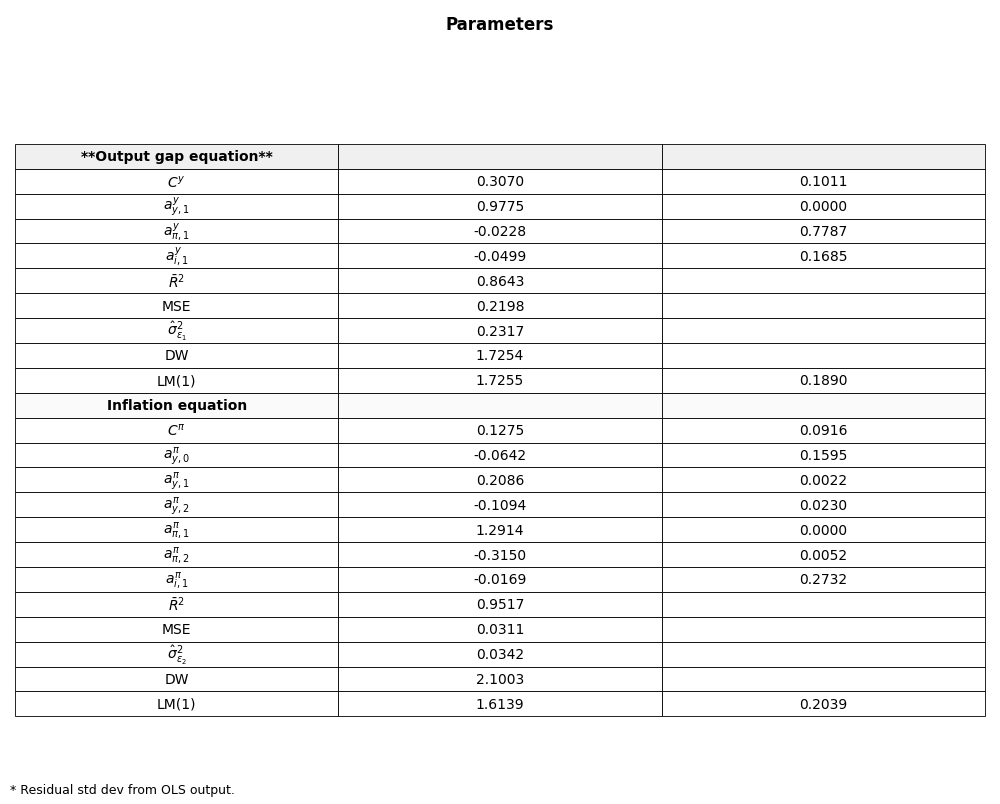

Saved: table9.png


In [303]:
def _is_md_separator_row(line: str) -> bool:
    s = line.strip()
    return s.startswith("|") and set(s.replace(" ", "")) <= set("|-:")

def _parse_md_row(line: str) -> list[str]:
    # "| a | b | c |" -> ["a","b","c"]
    return [c.strip() for c in line.strip().strip("|").split("|")]

def render_md_table_matplotlib(md: str, *, outpath: str = "table9.png", dpi: int = 300):
    # 1) collect rows (ignore the separator row)
    raw_rows = []
    for ln in str(md).splitlines():
        ln = ln.strip()
        if not ln:
            continue
        if _is_md_separator_row(ln):
            continue
        if ln.startswith("|") and ln.endswith("|"):
            raw_rows.append(_parse_md_row(ln))

    if len(raw_rows) < 2:
        raise ValueError("Not enough table rows found in md.")

    # 2) title + header + body
    title = raw_rows[0][0] if raw_rows[0] else "Table"
    col_labels = raw_rows[1]
    body = raw_rows[2:]

    # normalize column count
    ncols = len(col_labels)
    for r in range(len(body)):
        if len(body[r]) < ncols:
            body[r] = body[r] + [""] * (ncols - len(body[r]))
        elif len(body[r]) > ncols:
            body[r] = body[r][:ncols]

    # 3) figure sizing
    fig_h = max(2.0, 0.35 * (len(body) + 1))
    fig, ax = plt.subplots(figsize=(10, fig_h))
    ax.axis("off")
    fig.suptitle(title, fontsize=12, fontweight="bold", y=0.98)

    # 4) create table
    tbl = ax.table(
        cellText=body,
        colLabels=col_labels,
        cellLoc="center",
        colLoc="center",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.35)

    # 5) styling: header + section rows (**...**)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_linewidth(0.6)

        # header row (matplotlib uses r=0 for colLabels)
        if r == 0:
            cell.set_facecolor("#f0f0f0")
            cell.set_text_props(weight="bold")

    # body rows start at r=1 in the mpl table
    for i, row in enumerate(body, start=1):
        first = row[0].strip()
        if first.startswith("**") and first.endswith("**"):
            label = first.strip("*")
            # update text
            tbl[(i, 0)].get_text().set_text(label)
            # highlight whole row
            for c in range(ncols):
                tbl[(i, c)].set_facecolor("#fafafa")
                tbl[(i, c)].set_text_props(weight="bold")

    # 6) optional footnote (from your md)
    foot = None
    for ln in str(md).splitlines():
        if "Residual std dev" in ln:
            foot = ln.replace(r"\*", "*").strip()
            break
    if foot:
        fig.text(0.01, 0.01, foot, ha="left", va="bottom", fontsize=9)

    fig.tight_layout(rect=[0, 0.02, 1, 0.95])
    fig.savefig(outpath, dpi=dpi, bbox_inches="tight")
    return fig, ax, tbl

fig, ax, tbl = render_md_table_matplotlib(md, outpath="table9.png", dpi=300)
plt.show()
print("Saved:", "table9.png")

## Out-of-sample comparison: fitted linear environment vs. realized data

We evaluate how the estimated linear environment tracks realized macroeconomic dynamics after the training window. This is presented as a **descriptive out-of-sample comparison**, not a claim of structural stability across policy regimes (Lütkepohl, 2005).

### Out-of-sample window
The out-of-sample period begins at **2007Q3** and extends to the most recent available quarter. This split allows a clean separation between estimation and evaluation, highlighting performance during and after the Global Financial Crisis and subsequent regime changes. Out-of-sample series are retrieved using the same FRED interface and converted using the same `FredHelpers.to_pd_series` standardization step to ensure comparability between training and evaluation samples (Federal Reserve Bank of St. Louis, n.d.; Sunder, 2025).

In [304]:
import datetime

# Forecasting data Time Period: Q3 2007 - Now
os_start_date = "2007-07-01"
os_end_date = datetime.date.today().strftime("%Y-%m-%d")

In [305]:
# Fetch data from FRED
os_gdpdef_yoy = fred.get_series_observations(
    series_id="GDPDEF",
    observation_start=os_start_date,
    observation_end=os_end_date,
    frequency=freq,
    units="pc1"
)

os_real_gdp = fred.get_series_observations(
    series_id="GDPC1",
    observation_start=os_start_date,
    observation_end=os_end_date,
    frequency=freq,
    units="lin"
)

os_potential_gdp = fred.get_series_observations(
    series_id="GDPPOT",
    observation_start=os_start_date,
    observation_end=os_end_date,
    frequency=freq,
    units="lin"
)

os_effective_ffr = fred.get_series_observations(
    series_id="FEDFUNDS",
    observation_start=os_start_date,
    observation_end=os_end_date,
    frequency=freq,
    aggregation_method="avg"
)

# Convert to Series with proper names
os_pi = fed.FredHelpers.to_pd_series(os_gdpdef_yoy, "os_p")
os_y = fed.FredHelpers.to_pd_series(os_real_gdp, "os_y")
os_y_pot = fed.FredHelpers.to_pd_series(os_potential_gdp, "os_y_pot")
os_i = fed.FredHelpers.to_pd_series(os_effective_ffr, "i")


# Create y_gap series (Output Gap from Log Difference)
os_y_gap = 100.0 * (os_y / os_y_pot - 1.0)
os_y_gap.name = "os_y_gap"

# Check calculated series
print(os_pi.head())
print(os_pi.tail())
print(os_y_gap.head())
print(os_y_gap.tail())
print(os_i.head())
print(os_i.tail())

date
2007-07-01    2.57376
2007-10-01    2.62239
2008-01-01    2.03211
2008-04-01    1.81848
2008-07-01    2.02788
Name: os_p, dtype: float64
date
2024-10-01    2.46749
2025-01-01    2.57530
2025-04-01    2.46151
2025-07-01    2.97066
2025-10-01    3.28193
Name: os_p, dtype: float64
date
2007-07-01    1.213636
2007-10-01    1.338861
2008-01-01    0.406716
2008-04-01    0.527217
2008-07-01   -0.445713
Name: os_y_gap, dtype: float64
date
2025-01-01    0.570385
2025-04-01    0.944681
2025-07-01    1.464017
2025-10-01    1.262455
2026-01-01         NaN
Name: os_y_gap, dtype: float64
date
2007-07-01    5.07
2007-10-01    4.50
2008-01-01    3.18
2008-04-01    2.09
2008-07-01    1.94
Name: i, dtype: float64
date
2025-01-01    4.33
2025-04-01    4.33
2025-07-01    4.29
2025-10-01    3.90
2026-01-01     NaN
Name: i, dtype: float64


In [306]:
# Merge into one OOS DataFrame
df_oos = pd.concat([os_pi.rename("pi"), os_y_gap.rename("y"), os_i], axis=1).dropna().sort_index()
df_oos.index = df_oos.index.to_period("Q")

print(df_oos.head(), "\n")
print("OOS span:", df_oos.index.min(), "→", df_oos.index.max(), "| rows:", len(df_oos))

             pi         y     i
date                           
2007Q3  2.57376  1.213636  5.07
2007Q4  2.62239  1.338861  4.50
2008Q1  2.03211  0.406716  3.18
2008Q2  1.81848  0.527217  2.09
2008Q3  2.02788 -0.445713  1.94 

OOS span: 2007Q3 → 2025Q4 | rows: 74


### Forecast construction (design choice)
Forecasts are generated using the restricted estimated coefficients. Unless explicitly stated otherwise, the notebook uses **realized lagged values** as inputs rather than recursively feeding forecasted values back into the lag structure. This choice isolates one-step mapping performance from multi-step error accumulation.

In [307]:
# Set df_train reference
df_train = df.copy()

In [308]:
# Coefficients from your regression output
coef_y  = svar.mod_y.params.to_dict()
coef_pi = svar.mod_pi.params.to_dict()

# Iterative Print Loop (for output readability)
for key in coef_y.keys():
    print(f"{key}: {coef_y[key]:.4f}")

for key in coef_pi.keys():
    print(f"{key}: {coef_pi[key]:.4f}")

const: 0.3070
y_lag1: 0.9775
y_lag2: 0.0000
pi_lag1: -0.0228
pi_lag2: 0.0000
i_lag1: -0.0499
i_lag2: 0.0000
const: 0.1275
y: -0.0642
y_lag1: 0.2086
y_lag2: -0.1094
pi_lag1: 1.2914
pi_lag2: -0.3150
i_lag1: -0.0169
i_lag2: 0.0000


In [309]:
# ...existing code...

# Pull coefficients directly from your fitted models
coef_y  = svar.mod_y.params.to_dict()
coef_pi = svar.mod_pi.params.to_dict()

df_all = pd.concat([df_train, df_oos]).sort_index()
df_all["y_hat"]  = np.nan
df_all["pi_hat"] = np.nan

def lag_actual(t, col, k):
    """Always use actual historical data at lag k (no recursive use of forecasts)."""
    return df_all.at[t - k, col]

# start at a point where t-2 exists
start = max(df_all.index.min() + 2, pd.Period("2007Q3", "Q"))

for t in df_all.loc[start:].index:
    # --- Output gap: y_t (predicted, but using ONLY actual lag inputs) ---
    y_lag1  = lag_actual(t, "y", 1)
    pi_lag1 = lag_actual(t, "pi", 1)
    i_lag1  = lag_actual(t, "i", 1)
    i_lag2  = lag_actual(t, "i", 2)

    df_all.at[t, "y_hat"] = (
        coef_y["const"]
        + coef_y["y_lag1"]  * y_lag1
        + coef_y["pi_lag1"] * pi_lag1
        + coef_y["i_lag1"]  * i_lag1
        + coef_y["i_lag2"]  * i_lag2
    )

    # --- Inflation: pi_t (use ONLY actual inputs, including contemporaneous y_t) ---
    y_t     = df_all.at[t, "y"]          # <-- actual y_t, not y_hat
    y_lag1  = lag_actual(t, "y", 1)
    y_lag2  = lag_actual(t, "y", 2)
    pi_lag1 = lag_actual(t, "pi", 1)
    pi_lag2 = lag_actual(t, "pi", 2)
    i_lag1  = lag_actual(t, "i", 1)

    df_all.at[t, "pi_hat"] = (
        coef_pi["const"]
        + coef_pi["y"]       * y_t
        + coef_pi["y_lag1"]  * y_lag1
        + coef_pi["y_lag2"]  * y_lag2
        + coef_pi["pi_lag1"] * pi_lag1
        + coef_pi["pi_lag2"] * pi_lag2
        + coef_pi["i_lag1"]  * i_lag1
    )

# ...existing code...

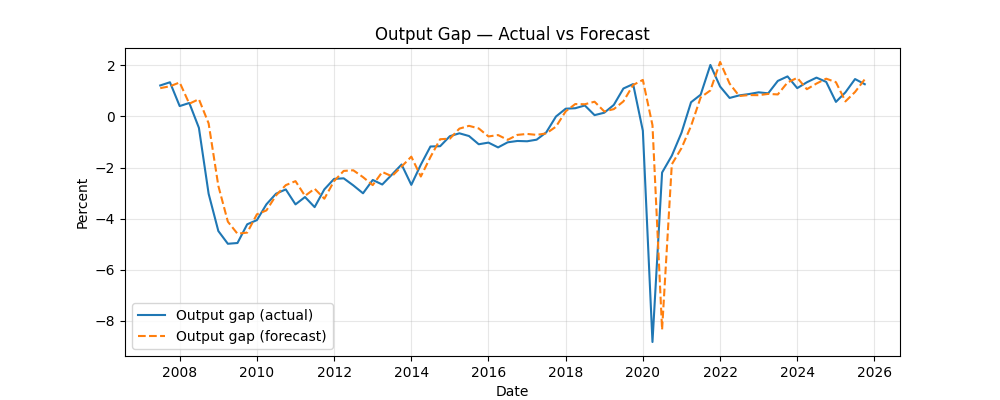

In [310]:
sub = df_all.loc["2007Q3":]

# Output gap
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sub.index.to_timestamp(), sub["y"], label="Output gap (actual)")
ax.plot(sub.index.to_timestamp(), sub["y_hat"], "--", label="Output gap (forecast)")
ax.set_title("Output Gap — Actual vs Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Percent")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Save figures for later use
figure_five = fig

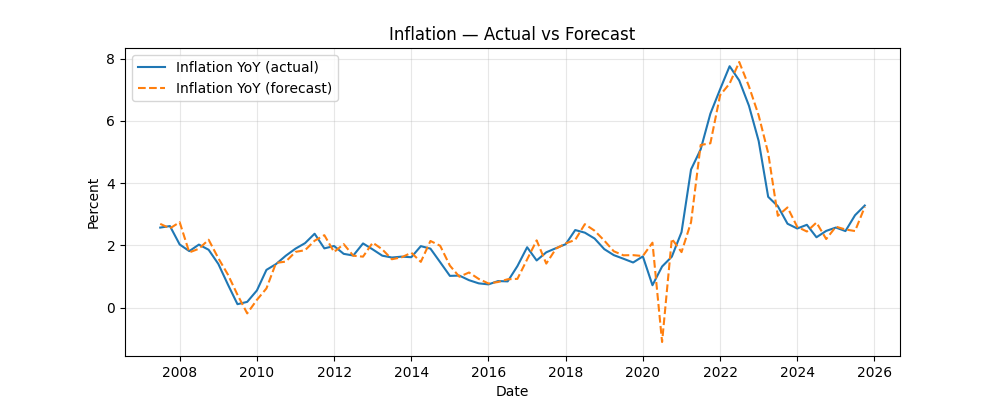

In [311]:
# Inflation
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sub.index.to_timestamp(), sub["pi"], label="Inflation YoY (actual)")
ax.plot(sub.index.to_timestamp(), sub["pi_hat"], "--", label="Inflation YoY (forecast)")
ax.set_title("Inflation — Actual vs Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Percent")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Save figures for later use
figure_six = fig

## In-sample fit and error diagnostics

To benchmark the linear environment on the estimation sample, we compute fitted values and squared errors for both equations. These diagnostics indicate whether the restricted SVAR captures the primary short-run dynamics within the training window (Lütkepohl, 2005).

In [312]:
# Training window (paper window)
df_train = df.loc["1987Q3":"2007Q2"].copy()

# Predict on the exact in-sample design matrices
y_fit  = svar.mod_y.predict(svar.X_y)
pi_fit = svar.mod_pi.predict(svar.X_pi)

# Sanity: indexes should match design matrices you trained on
assert y_fit.index.equals(svar.X_y.index)
assert pi_fit.index.equals(svar.X_pi.index)

# Build aligned frame on the training index
fit_df = pd.DataFrame(index=df_train.index)
fit_df["y_actual"]  = df_train["y"]
fit_df["pi_actual"] = df_train["pi"]
fit_df["y_fit"]     = y_fit.reindex(fit_df.index)
fit_df["pi_fit"]    = pi_fit.reindex(fit_df.index)

# Residuals (in-sample)
resid_y  = (fit_df["y_actual"]  - fit_df["y_fit"])
resid_pi = (fit_df["pi_actual"] - fit_df["pi_fit"])

# Squared errors
fit_df["se_y_svar"]  = resid_y**2
fit_df["se_pi_svar"] = resid_pi**2

# Drop rows without a fitted value (initial lags)
fit_df = fit_df.dropna(subset=["y_fit","pi_fit"])

# Quick diagnostics
print(fit_df[["se_y_svar","se_pi_svar"]].head())
print("In-sample std(resid):",
      round(resid_y.dropna().std(), 3),
      round(resid_pi.dropna().std(), 3))

        se_y_svar  se_pi_svar
date                         
1988Q1   0.015276    0.000237
1988Q2   0.442241    0.120509
1988Q3   0.000026    0.107042
1988Q4   0.633361    0.002650
1989Q1   0.279251    0.065931
In-sample std(resid): 0.472 0.178


### Figure 4 Output Gap Fit: Squared Errors

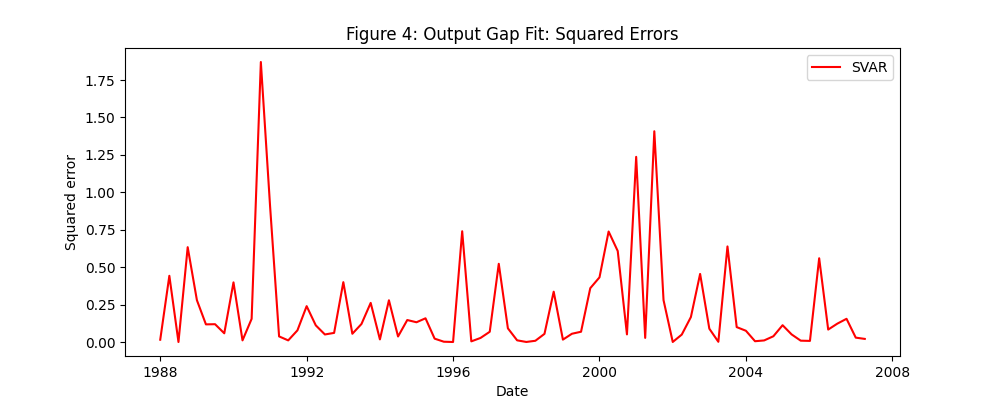

In [313]:
# Figure 4: Output gap fit — squared errors
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fit_df.index.to_timestamp(), fit_df["se_y_svar"], color="red", label="SVAR", linewidth=1.5)
ax.set_title("Figure 4: Output Gap Fit: Squared Errors")
ax.set_xlabel("Date"); ax.set_ylabel("Squared error"); ax.grid(False)
ax.legend()
plt.show()

# Save figures for later use
figure_four = fig

### Figure 5 Inflation Fit: Squared Errors

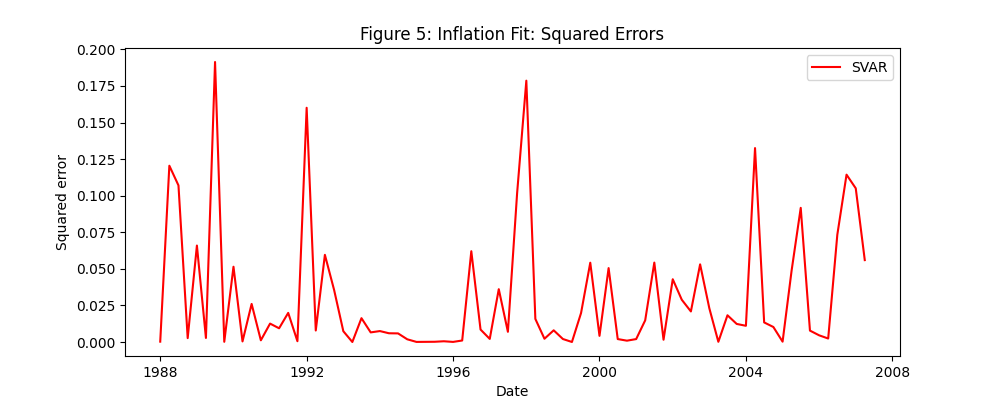

In [314]:
# Figure 5: Inflation fit — squared errors
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fit_df.index.to_timestamp(), fit_df["se_pi_svar"], color="red", label="SVAR", linewidth=1.5)
ax.set_title("Figure 5: Inflation Fit: Squared Errors")
ax.set_xlabel("Date"); ax.set_ylabel("Squared error"); ax.grid(False)
ax.legend()
plt.show()

# Save figures for later use
figure_five = fig

Note: The y-axis scale is different from the paper due to our model using the correct units (YoY percent, not decimals). In addition The smaller squared errors reflect a tighter fit in the replication relative to the Bundesbank baseline

--------

# Alternative Specification: Rolling-Window SVAR(2) (Unrestricted)

This section estimates a robustness variant of the baseline linear environment. Instead of restricting the SVAR(2) by recursively dropping statistically weak second-lag terms, we estimate an **unrestricted SVAR(2)** on a **rolling window**. The rolling-window design allows the effective law of motion to vary over time by re-estimating parameters on a moving subsample, which is a standard device when forecast performance may be affected by **structural change** or **parameter instability** (Clements & Hendry, 1998; Stock & Watson, 2007). Identification follows the same recursive ordering used in the baseline SVAR (Sims, 1980; Lütkepohl, 2005).

## Data (unchanged)

The observable definitions and transformations are unchanged relative to the baseline specification. All series are retrieved from FRED and standardized using `fedfred`’s built-in conversion helper to obtain consistent quarterly `pandas.Series` objects prior to merging and lag construction (Federal Reserve Bank of St. Louis, n.d.; Sunder, 2025).

In [315]:
# Fetch data from FRED
gdpdef_yoy = fred.get_series_observations(
    series_id="GDPDEF",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    units="pc1" # YoY percent change
)

real_gdp = fred.get_series_observations(
    series_id="GDPC1",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    units="lin" # Linear units (level)
)

potential_gdp = fred.get_series_observations(
    series_id="GDPPOT",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    units="lin" # Linear units (level)
)

effective_ffr = fred.get_series_observations(
    series_id="FEDFUNDS",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    aggregation_method="avg" # Aggregate daily data to quarterly by averaging (specificly important for interest rates)
)

# Check data
print(gdpdef_yoy.head())
print(real_gdp.head())
print(potential_gdp.head())
print(effective_ffr.head())

           realtime_start realtime_end    value
date                                           
1987-07-01     2026-02-20   2026-02-20  2.66122
1987-10-01     2026-02-20   2026-02-20  2.91876
1988-01-01     2026-02-20   2026-02-20  3.06577
1988-04-01     2026-02-20   2026-02-20  3.35274
1988-07-01     2026-02-20   2026-02-20  3.80207
           realtime_start realtime_end     value
date                                            
1987-07-01     2026-02-20   2026-02-20  9162.024
1987-10-01     2026-02-20   2026-02-20  9319.332
1988-01-01     2026-02-20   2026-02-20  9367.502
1988-04-01     2026-02-20   2026-02-20  9490.594
1988-07-01     2026-02-20   2026-02-20  9546.206
           realtime_start realtime_end        value
date                                               
1987-07-01     2026-03-02   2026-03-02  9191.505940
1987-10-01     2026-03-02   2026-03-02  9262.554077
1988-01-01     2026-03-02   2026-03-02  9332.898162
1988-04-01     2026-03-02   2026-03-02  9402.936119
1988-07-0

## Rolling estimation design

### Window length and evaluation period

Let ${W}$ denote the rolling window length in quarters. In this alternative specification we use a **short rolling window**, ${W=4}$ (1 year) **throughout**.

For each evaluation quarter ${t}$, the SVAR(2) is estimated on the trailing subsample ${[t-W,\;t-1]}$, and one-step-ahead
fitted values ${(\hat y_t,\hat\pi_t)}$ are computed using realized regressors. This produces a time series of locally
re-estimated parameters $\{\hat\theta_t\}$ and fitted values that can adapt to changing reduced-form relationships.

Because ${W=4}$ is short, rolling estimates may be noisier than long-window variants; the objective is to stress-test
time-variation rather than to maximize estimation precision.

### Rolling sample and no-look-ahead rule

For each quarter ${t}$, the rolling SVAR(2) is estimated using only the trailing subsample ${[t-W,\;t-1]}$ with ${W=4}$.
This enforces a strict **no-look-ahead** rule: parameters used to form ${(\hat y_t,\hat\pi_t)}$ depend only on information
available prior to quarter ${t}$.

Implementation-wise, the rolling code requires a single quarterly panel containing ${\pi_t}$, ${y_t}$, and ${i_t}$ over the
span where rolling fitted values are desired. The notebook uses a quarterly `PeriodIndex` so that lag operations
(${t-1}$, ${t-2}$) are well-defined.

### Implementation: Rolling Unrestricted SVAR(2)

In [316]:
# Rolling Unrestricted Recursive SVAR(2)
def fit_unrestricted_svar_window(df_window: pd.DataFrame):
    """
    Fit unrestricted recursive SVAR(2) via equation-by-equation OLS.
    No lag dropping.
    """

    work = df_window.copy()

    # Construct lags
    for c in ("pi", "y", "i"):
        work[f"{c}_lag1"] = work[c].shift(1)
        work[f"{c}_lag2"] = work[c].shift(2)

    # Output gap equation
    y_target = work["y"]
    X_y = work[["y_lag1", "y_lag2",
                "pi_lag1", "pi_lag2",
                "i_lag1", "i_lag2"]]
    X_y = sm.add_constant(X_y, has_constant="add")

    mask_y = X_y.notna().all(axis=1) & y_target.notna()
    X_y = X_y.loc[mask_y]
    y_target = y_target.loc[mask_y]

    mod_y = sm.OLS(y_target, X_y).fit()

    # Inflation equation
    pi_target = work["pi"]
    X_pi = work[["y", "y_lag1", "y_lag2",
                 "pi_lag1", "pi_lag2",
                 "i_lag1", "i_lag2"]]
    X_pi = sm.add_constant(X_pi, has_constant="add")

    mask_pi = X_pi.notna().all(axis=1) & pi_target.notna()
    X_pi = X_pi.loc[mask_pi]
    pi_target = pi_target.loc[mask_pi]

    mod_pi = sm.OLS(pi_target, X_pi).fit()

    return mod_y, mod_pi

### Estimation details (unrestricted, equation-by-equation)

Within each rolling window, both equations are estimated by OLS **without** post-estimation lag selection.
That is, all first- and second-lag regressors are retained in every window:

- Output-gap equation regressors: $(y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2})$
- Inflation equation regressors: $(y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2})$

This differs from the baseline specification, where the second-lag terms may be dropped based on full-sample
significance. Here, coefficient variation is driven by **window re-estimation** rather than explicit restriction.

## Unrestricted recursive SVAR(2)

Let the state vector include output gap ${y_t}$, inflation ${\pi_t}$, and the policy rate ${i_t}$. The rolling specification retains the same recursive ordering as the baseline, while **retaining all first- and second-lag regressors** (no lag dropping).

1. **Output-gap equation (reduced form)**
$$
y_t = C^y + a^y_{y,1}y_{t-1} + a^y_{y,2}y_{t-2}
      + a^y_{\pi,1}\pi_{t-1} + a^y_{\pi,2}\pi_{t-2}
      + a^y_{i,1}i_{t-1} + a^y_{i,2}i_{t-2} + \varepsilon^y_t.
$$

2. **Inflation equation (recursive ordering)**
$$
\pi_t = C^\pi + a^\pi_{y,0}y_{t} + a^\pi_{y,1}y_{t-1} + a^\pi_{y,2}y_{t-2}
        + a^\pi_{\pi,1}\pi_{t-1} + a^\pi_{\pi,2}\pi_{t-2}
        + a^\pi_{i,1}i_{t-1} + a^\pi_{i,2}i_{t-2} + \varepsilon^\pi_t.
$$

Each equation is estimated by OLS within the rolling window. The recursive contemporaneous term $y_t$ in the inflation equation corresponds to a standard triangular (Cholesky-style) ordering used in VAR/SVAR applications (Sims, 1980; Lütkepohl, 2005).

## Rolling fit diagnostics

With rolling estimation using $W=4$, the core diagnostics are:

- **In-sample (1987Q3–2007Q2):** squared errors from the rolling fitted values (Figures 4–5, Alt Spec).
- **Out-of-sample (2007Q3 onward):** actual vs. rolling fitted values and/or squared errors computed from the rolling loop.

Squared errors are defined as:
$$
SE^y_t = (y_t - \hat y_t)^2,\qquad SE^\pi_t = (\pi_t - \hat\pi_t)^2.
$$

Optional summaries (e.g., mean squared error) can be reported over any chosen evaluation subsample.


In [317]:
# In-sample rolling (ALT) + Figure 4 (ALT): Output gap squared errors over training sample

# define in-sample window (match baseline training period)
df_train_is = df_all.loc["1987Q3":"2007Q2"].copy()

# choose an in-sample rolling window shorter than the training sample
W_is = 4  # e.g., 4 quarters (1 year). Must be < len(df_train_is)

df_roll_is = df_train_is.copy()
df_roll_is["y_hat_roll_is"] = np.nan
df_roll_is["pi_hat_roll_is"] = np.nan

# rolling one-step-ahead within the in-sample period
for t in df_roll_is.index[W_is + 2:]:  # ensure 2 lags exist
    window_start = t - W_is
    window_end = t - 1
    df_window = df_roll_is.loc[window_start:window_end]

    if len(df_window) < W_is:
        continue

    mod_y, mod_pi = fit_unrestricted_svar_window(df_window)

    # realized lag inputs
    y_lag1 = df_roll_is.at[t - 1, "y"]
    y_lag2 = df_roll_is.at[t - 2, "y"]
    pi_lag1 = df_roll_is.at[t - 1, "pi"]
    pi_lag2 = df_roll_is.at[t - 2, "pi"]
    i_lag1 = df_roll_is.at[t - 1, "i"]
    i_lag2 = df_roll_is.at[t - 2, "i"]
    y_t_actual = df_roll_is.at[t, "y"]  # conditional inflation fit

    df_roll_is.at[t, "y_hat_roll_is"] = (
        mod_y.params["const"]
        + mod_y.params["y_lag1"] * y_lag1
        + mod_y.params["y_lag2"] * y_lag2
        + mod_y.params["pi_lag1"] * pi_lag1
        + mod_y.params["pi_lag2"] * pi_lag2
        + mod_y.params["i_lag1"] * i_lag1
        + mod_y.params["i_lag2"] * i_lag2
    )

    df_roll_is.at[t, "pi_hat_roll_is"] = (
        mod_pi.params["const"]
        + mod_pi.params["y"] * y_t_actual
        + mod_pi.params["y_lag1"] * y_lag1
        + mod_pi.params["y_lag2"] * y_lag2
        + mod_pi.params["pi_lag1"] * pi_lag1
        + mod_pi.params["pi_lag2"] * pi_lag2
        + mod_pi.params["i_lag1"] * i_lag1
        + mod_pi.params["i_lag2"] * i_lag2
    )

### Figure 4 (Alt Spec, In-Sample): Output Gap Fit — Squared Errors (Rolling, $W=4$)

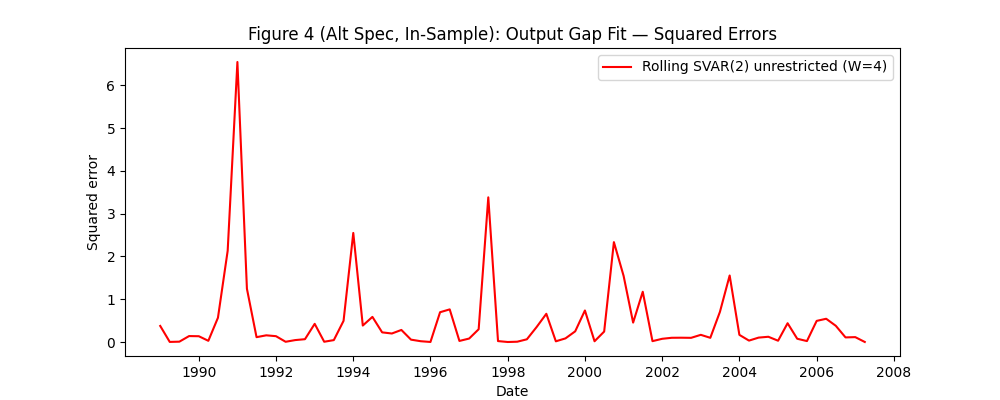

In [318]:
# Figure 4 (ALT, in-sample): squared errors for output gap
df_roll_is["se_y_roll_is"] = (df_roll_is["y"] - df_roll_is["y_hat_roll_is"]) ** 2
plot_y = df_roll_is.dropna(subset=["se_y_roll_is"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    plot_y.index.to_timestamp(),
    plot_y["se_y_roll_is"],
    color="red",
    linewidth=1.5,
    label=f"Rolling SVAR(2) unrestricted (W={W_is})",
)
ax.set_title("Figure 4 (Alt Spec, In-Sample): Output Gap Fit — Squared Errors")
ax.set_xlabel("Date")
ax.set_ylabel("Squared error")
ax.grid(False)
ax.legend()
plt.show()

figure_four_alt = fig

### Figure 5 (Alt Spec, In-Sample): Inflation Fit — Squared Errors (Rolling, $W=4$, conditional $\hat\pi_t$)

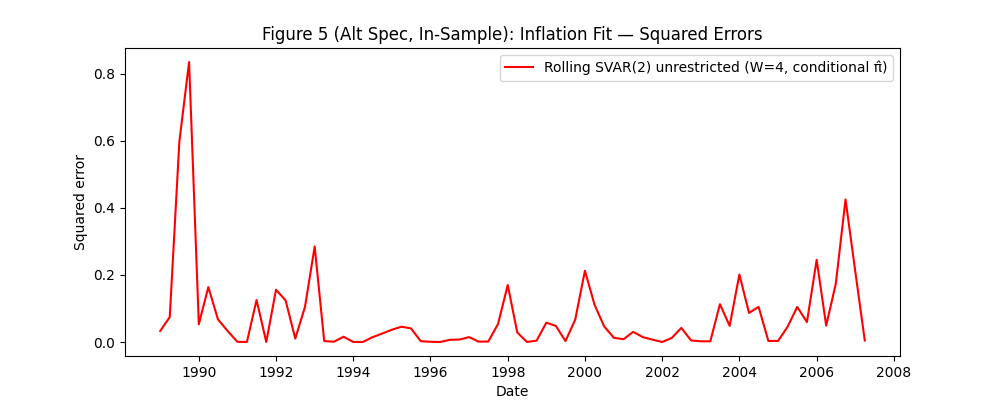

In [319]:
# Figure 5 (ALT, in-sample): Inflation squared errors over training sample
df_roll_is["se_pi_roll_is"] = (df_roll_is["pi"] - df_roll_is["pi_hat_roll_is"]) ** 2
plot_pi = df_roll_is.dropna(subset=["se_pi_roll_is"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    plot_pi.index.to_timestamp(),
    plot_pi["se_pi_roll_is"],
    color="red",
    linewidth=1.5,
    label=f"Rolling SVAR(2) unrestricted (W={W_is}, conditional π̂)",
)
ax.set_title("Figure 5 (Alt Spec, In-Sample): Inflation Fit — Squared Errors")
ax.set_xlabel("Date")
ax.set_ylabel("Squared error")
ax.grid(False)
ax.legend()
plt.show()

figure_five_alt = fig

**Interpretation note (short-window rolling):** With $W=4$, each window contains limited information relative to an
SVAR(2) with multiple regressors, so squared errors can be volatile. These plots are therefore best read as a diagnostic
for **time variation / instability** under aggressive re-estimation rather than as a precision-optimized fit measure.

## Forecast construction and interpretation

### One-step-ahead mapping
For each quarter ${t}$, we compute one-step fitted values using the coefficients estimated on ${[t-W,\,t-1]}$. Unless explicitly stated otherwise, the regressors are formed from **realized** lagged values $(y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2})$. This isolates the quality of the local linear mapping from the accumulation of multi-step forecast error.

### Conditional vs. fully model-based inflation prediction
Because the recursive ordering includes contemporaneous ${y_t}$ in the inflation equation, ${\hat \pi_t}$ can be computed either:
- **Conditionally**, using the realized ${y_t}$ (interpretable as a partial-equilibrium or conditional forecast), or
- **Fully model-based**, substituting ${y_t}$ with ${\hat y_t}$ from the rolling output-gap equation.

The notebook reports the conditional version by default to separate coefficient drift from feedback error introduced by recursive substitution.

### Forecast inputs used in the rolling loop

The rolling loop produces one-step-ahead fitted values using **realized lagged inputs** from the data:

- ${\hat y_t}$ uses $(y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2})$.
- ${\hat\pi_t}$ is computed **conditionally** using realized contemporaneous ${y_t}$ (i.e., the recursive term is treated as observed).

The conditional inflation fit isolates variation coming from rolling coefficients and lag dynamics, and avoids
additional error propagation that would occur if $y_t$ were replaced by $\hat y_t$ inside the inflation equation.

### Rolling Forecast Loop

In [320]:
# Rolling Forecast Procedure
W = 4 # window length (quarters)

df_roll = df_all.copy()
df_roll["y_hat_roll"] = np.nan
df_roll["pi_hat_roll"] = np.nan

for t in df_roll.index[W+2:]: # ensure 2 lags exist

    window_start = t - W
    window_end = t - 1

    df_window = df_roll.loc[window_start:window_end]

    if len(df_window) < W:
        continue

    mod_y, mod_pi = fit_unrestricted_svar_window(df_window)

    # Actual lag inputs 
    y_lag1 = df_roll.at[t-1, "y"]
    y_lag2 = df_roll.at[t-2, "y"]
    pi_lag1 = df_roll.at[t-1, "pi"]
    pi_lag2 = df_roll.at[t-2, "pi"]
    i_lag1 = df_roll.at[t-1, "i"]
    i_lag2 = df_roll.at[t-2, "i"]
    y_t_actual = df_roll.at[t, "y"] # conditional inflation forecast

    # y forecast 
    df_roll.at[t, "y_hat_roll"] = (
        mod_y.params["const"]
        + mod_y.params["y_lag1"] * y_lag1
        + mod_y.params["y_lag2"] * y_lag2
        + mod_y.params["pi_lag1"] * pi_lag1
        + mod_y.params["pi_lag2"] * pi_lag2
        + mod_y.params["i_lag1"] * i_lag1
        + mod_y.params["i_lag2"] * i_lag2
    )

    # pi forecast (conditional on actual y_t)
    df_roll.at[t, "pi_hat_roll"] = (
        mod_pi.params["const"]
        + mod_pi.params["y"] * y_t_actual
        + mod_pi.params["y_lag1"] * y_lag1
        + mod_pi.params["y_lag2"] * y_lag2
        + mod_pi.params["pi_lag1"] * pi_lag1
        + mod_pi.params["pi_lag2"] * pi_lag2
        + mod_pi.params["i_lag1"] * i_lag1
        + mod_pi.params["i_lag2"] * i_lag2
    )

## Out-of-sample evaluation (Rolling SVAR(2), unrestricted, $W=4$)

We evaluate the rolling-window SVAR(2) on the post-training period starting in **2007Q3**. For each quarter ${t}$, model
parameters are re-estimated using only the trailing subsample ${[t-W,\;t-1]}$ with ${W=4}$, and one-step-ahead fitted
values ${(\hat y_t,\hat\pi_t)}$ are constructed using **realized** lagged inputs.

Because the rolling SVAR(2) requires two lags and a full estimation window, fitted values are not available for the first
few out-of-sample observations. The code therefore reports error metrics and plots using only quarters where fitted values
exist.

In [321]:
# Out-of-sample: Actual vs Rolling SVAR(2) fitted (W=4)

# OOS slice
oos = df_roll.loc["2007Q3":].copy()

# Errors (defined even if some fitted values are NaN early on)
oos["err_y_roll"]  = oos["y"]  - oos["y_hat_roll"]
oos["err_pi_roll"] = oos["pi"] - oos["pi_hat_roll"]
oos["se_y_roll"]   = oos["err_y_roll"] ** 2
oos["se_pi_roll"]  = oos["err_pi_roll"] ** 2

# Drop rows where fitted values don't exist yet (due to lags + window)
oos_y  = oos.dropna(subset=["y_hat_roll"])
oos_pi = oos.dropna(subset=["pi_hat_roll"])

# Summary metrics
mse_y  = float(oos_y["se_y_roll"].mean())
rmse_y = mse_y ** 0.5
mse_pi  = float(oos_pi["se_pi_roll"].mean())
rmse_pi = mse_pi ** 0.5

print(f"OOS (from 2007Q3) Rolling W={W} | y:  MSE={mse_y:.4f}, RMSE={rmse_y:.4f}, n={len(oos_y)}")
print(f"OOS (from 2007Q3) Rolling W={W} | pi: MSE={mse_pi:.4f}, RMSE={rmse_pi:.4f}, n={len(oos_pi)}")

OOS (from 2007Q3) Rolling W=4 | y:  MSE=22.4364, RMSE=4.7367, n=74
OOS (from 2007Q3) Rolling W=4 | pi: MSE=0.4601, RMSE=0.6783, n=74


### Out-of-sample tracking: output gap (${y_t}$)

The figure compares the realized output gap ${y_t}$ to the rolling SVAR fitted value ${\hat y_t}$ for the out-of-sample
period (2007Q3 onward). This is a descriptive assessment of how the locally re-estimated linear mapping tracks realized
dynamics under potential structural change.

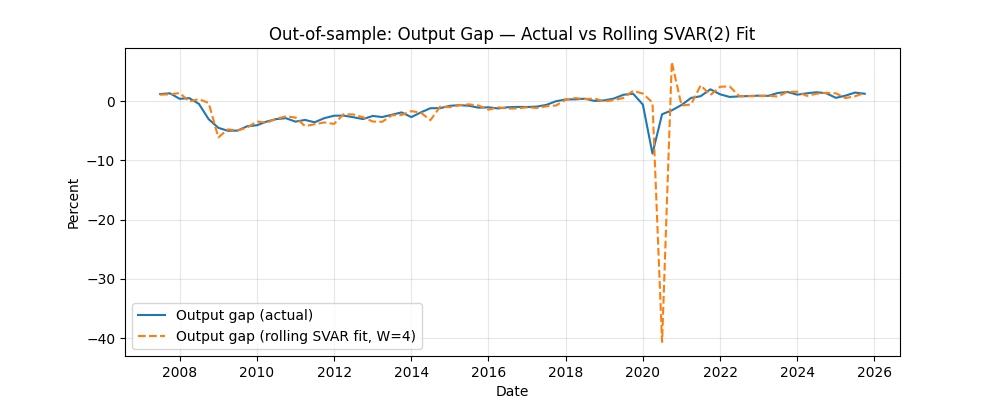

In [322]:
# Plot: Output gap
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(oos_y.index.to_timestamp(), oos_y["y"], label="Output gap (actual)")
ax.plot(oos_y.index.to_timestamp(), oos_y["y_hat_roll"], "--", label=f"Output gap (rolling SVAR fit, W={W})")
ax.set_title("Out-of-sample: Output Gap — Actual vs Rolling SVAR(2) Fit")
ax.set_xlabel("Date")
ax.set_ylabel("Percent")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### Out-of-sample tracking: inflation ($\pi_t$, conditional fit)

Because the recursive ordering includes contemporaneous ${y_t}$ in the inflation equation, the rolling inflation fitted
value ${\hat\pi_t}$ is computed **conditionally** using realized ${y_t}$ (rather than substituting ${\hat y_t}$). This
choice isolates coefficient drift and lag dynamics from additional error propagation due to recursive substitution.

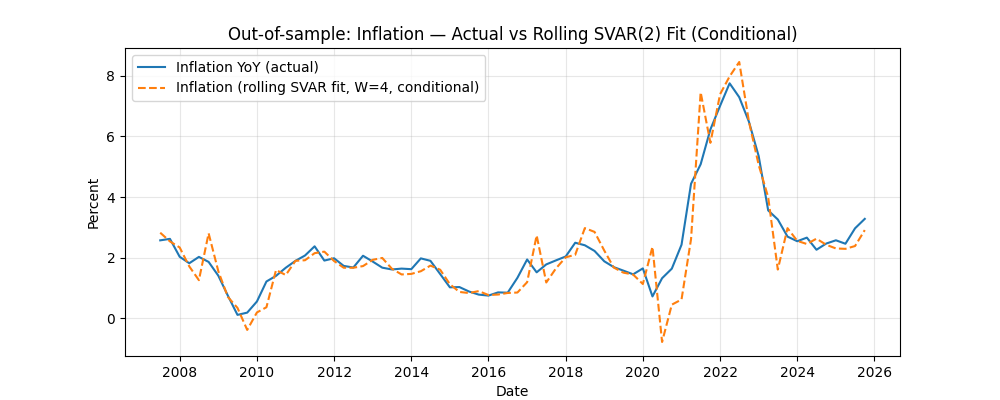

In [323]:
# Plot: Inflation (conditional on actual y_t, as implemented in your loop)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(oos_pi.index.to_timestamp(), oos_pi["pi"], label="Inflation YoY (actual)")
ax.plot(oos_pi.index.to_timestamp(), oos_pi["pi_hat_roll"], "--", label=f"Inflation (rolling SVAR fit, W={W}, conditional)")
ax.set_title("Out-of-sample: Inflation — Actual vs Rolling SVAR(2) Fit (Conditional)")
ax.set_xlabel("Date")
ax.set_ylabel("Percent")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### Out-of-sample error metrics

For completeness, we summarize out-of-sample performance using mean squared error (MSE) and root mean squared error
(RMSE) over the post-2007Q3 subsample where rolling fitted values are available:
$$
\text{MSE}^m = \frac{1}{T}\sum_t (x_t^m-\hat x_t^m)^2,\qquad
\text{RMSE}^m = \sqrt{\text{MSE}^m},\quad m\in\{y,\pi\}.
$$
These metrics are reported separately for the output gap and inflation series.

## What this robustness check evaluates

Relative to a fixed-parameter SVAR estimated on a long pre-crisis window, rolling estimation tests whether allowing parameters to adapt improves descriptive out-of-sample tracking when the economy undergoes regime shifts (e.g., the Global Financial Crisis and the effective lower bound period). Evidence that the rolling SVAR improves fit is consistent with time variation in reduced-form relationships, a common explanation for macro forecast instability (Stock & Watson, 2007; Clements & Hendry, 1998).

### Interpretation caveats

Rolling estimation trades off flexibility and precision: using shorter windows can adapt to structural change,
but increases sampling variation in the coefficient estimates. Accordingly, improvements in rolling tracking
should be interpreted as evidence consistent with **time variation in reduced-form relationships**, not as
structural identification or policy-invariance.

--------

# Modern Specification: Recursive TVP with Stochastic Volatility (TVP‑SV)

This section replaces fixed‑parameter estimation with a **time‑varying parameter (TVP)** reduced form and **stochastic volatility (SV)**. The aim is to allow (i) gradual drift in the reduced‑form mapping and (ii) time‑varying shock uncertainty—features commonly used to model evolving macroeconomic dynamics and volatility (Cogley & Sargent, 2005; Primiceri, 2005). Relative to a rolling SVAR, TVP‑SV treats coefficient changes as **latent state evolution** rather than repeated re‑estimation on a moving window (Stock & Watson, 2007; Clements & Hendry, 1998).

To remain comparable to the baseline recursive SVAR(2), we keep the same **triangular (recursive) ordering** and estimate the system **equation‑by‑equation**, consistent with the recursive (Cholesky‑style) logic widely used in VAR/SVAR applications (Sims, 1980; Lütkepohl, 2005).


## Model (observation equations)

Let ${t=1,\dots,T}$ index quarters and define the observables: output gap ${y_t}$, inflation ${\pi_t}$, and policy rate ${i_t}$.
To match the notebook’s **implemented recursive design matrices**, we estimate two TVP regression equations:

### Output gap equation (TVP)
$$
y_t = X_t^{y}\,\beta_t^{y} + \varepsilon_t^{y},
$$
with
$$
X_t^{y}=\left[1,\; y_{t-1},\; y_{t-2},\; \pi_{t-1},\; \pi_{t-2},\; i_{t-1},\; i_{t-2}\right].
$$

### Inflation equation (TVP, recursive / triangular)
$$
\pi_t = X_t^{\pi}\,\beta_t^{\pi} + \varepsilon_t^{\pi},
$$
with
$$
X_t^{\pi}=\left[1,\; y_{t},\; y_{t-1},\; y_{t-2},\; \pi_{t-1},\; \pi_{t-2},\; i_{t-1},\; i_{t-2}\right].
$$

Including contemporaneous ${y_t}$ in the inflation equation implements a **recursive (triangular) structure**, analogous to Cholesky‑ordered VAR/SVAR systems (Sims, 1980; Lütkepohl, 2005). Throughout, the specification is interpreted as a **reduced‑form** environment rather than a fully structural causal model.

## State evolution (time variation in coefficients)

For each equation $m\in\{y,\pi\}$, the coefficient vector follows a random walk:
$$
\beta_t^{m} = \beta_{t-1}^{m} + u_t^{m}, \qquad u_t^{m}\sim \mathcal{N}(0,Q_m).
$$
This state equation captures gradual parameter drift in the spirit of standard TVP macroeconometric specifications (Cogley & Sargent, 2005; Primiceri, 2005).

## Stochastic volatility (SV)

Each equation’s disturbance variance evolves over time via a log‑variance random walk:
$$
\varepsilon_t^{m} \sim \mathcal{N}\!\left(0,\sigma_{m,t}^{2}\right), 
\qquad \sigma_{m,t}^{2}=\exp(h_{m,t}),
$$
$$
h_{m,t}=h_{m,t-1}+\eta_{m,t},\qquad \eta_{m,t}\sim\mathcal{N}(0,W_m).
$$
Allowing $\sigma_{m,t}^{2}$ to vary accommodates time‑varying macro uncertainty and volatility consistent with empirical TVP‑SV evidence (Cogley & Sargent, 2005; Primiceri, 2005).

## Inference (ADVI -> NUTS) and reported fitted values

TVP‑SV models are high‑dimensional because they infer full latent paths $\{\beta_t^{m}\}_{t=1}^T$ and $\{h_{m,t}\}_{t=1}^T$. The notebook therefore uses a two‑stage Bayesian workflow:
1. **ADVI** to obtain a stable approximation and initialize latent states.
2. **NUTS** to generate posterior draws from the joint distribution of \(\beta_t^{m}\) and \(h_{m,t}\).

For each equation ${m}$, we report the posterior mean fitted path
$$
\hat{x}_t^{m} \equiv \mathbb{E}\!\left[X_t^{m}\beta_t^{m}\mid \text{data}\right],
$$
and (optionally) pointwise credible bands for $\mu_t^{m}=X_t^{m}\beta_t^{m}$ computed from posterior quantiles (Cogley & Sargent, 2005; Primiceri, 2005).

In [324]:
%pip install --quiet pymc arviz pytensor

Note: you may need to restart the kernel to use updated packages.


In [325]:
import pymc as pm
import arviz as az
import pytensor.tensor as pt

In [326]:
def make_recursive_svar_design(df: pd.DataFrame):
    """
    Build design matrices that match the recursive rolling SVAR(2) implementation:

      y_t  ~ const + y_{t-1},y_{t-2},pi_{t-1},pi_{t-2},i_{t-1},i_{t-2}
      pi_t ~ const + y_t,y_{t-1},y_{t-2},pi_{t-1},pi_{t-2},i_{t-1},i_{t-2}

    Returns arrays aligned on a common PeriodIndex (drops initial lags).
    """
    work = df.loc[:, ["y", "pi", "i"]].copy().sort_index()

    # lags
    for c in ("y", "pi", "i"):
        work[f"{c}_lag1"] = work[c].shift(1)
        work[f"{c}_lag2"] = work[c].shift(2)

    # X blocks (match rolling)
    Xy_df = work[["y_lag1", "y_lag2", "pi_lag1", "pi_lag2", "i_lag1", "i_lag2"]].copy()
    Xy_df = sm.add_constant(Xy_df, has_constant="add")

    Xpi_df = work[["y", "y_lag1", "y_lag2", "pi_lag1", "pi_lag2", "i_lag1", "i_lag2"]].copy()
    Xpi_df = sm.add_constant(Xpi_df, has_constant="add")

    y_df = work[["y"]].copy()
    pi_df = work[["pi"]].copy()

    # common mask (so both equations share the same time index)
    mask = (
        Xy_df.notna().all(axis=1)
        & Xpi_df.notna().all(axis=1)
        & y_df.notna().all(axis=1)
        & pi_df.notna().all(axis=1)
    )

    Xy_df = Xy_df.loc[mask]
    Xpi_df = Xpi_df.loc[mask]
    y_df = y_df.loc[mask]
    pi_df = pi_df.loc[mask]

    idx = Xy_df.index
    return (
        y_df["y"].to_numpy(),
        Xy_df.to_numpy(),
        pi_df["pi"].to_numpy(),
        Xpi_df.to_numpy(),
        idx,
        list(Xy_df.columns),
        list(Xpi_df.columns),
    )

In [327]:
def fit_tvp_rw_sv_univariate(Y: np.ndarray, X: np.ndarray, *, idx: pd.PeriodIndex, reg_names: list[str], seed: int = 123):
    """
    Univariate TVP regression with:
      beta_t = beta_{t-1} + u_t   (random walk)
      log(sigma_t^2) = h_t,  h_t = h_{t-1} + eta_t  (RW stochastic volatility, diagonal)

    Returns idata with deterministic 'mu' and 'sigma_obs'.
    """
    T = int(Y.shape[0])
    k = int(X.shape[1])

    coords = {
        "time": np.arange(T),
        "time_m1": np.arange(T - 1),
        "reg": reg_names,
    }

    with pm.Model(coords=coords) as m:
        X_data = pm.Data("X", X, dims=("time", "reg"))
        Y_data = pm.Data("Y", Y, dims=("time",))

        # state innovation scales
        sigma_beta = pm.Exponential("sigma_beta", 5.0, dims=("reg",))
        sigma_h = pm.Exponential("sigma_h", 5.0)

        # coefficient RW
        beta0 = pm.Normal("beta0", 0.0, 1.0, dims=("reg",))
        beta_innov = pm.Normal("beta_innov", 0.0, sigma_beta, dims=("time_m1", "reg"))
        beta_path = pt.concatenate(
            [beta0[None, :], beta0[None, :] + pt.cumsum(beta_innov, axis=0)],
            axis=0,
        )
        beta = pm.Deterministic("beta", beta_path, dims=("time", "reg"))

        # log-vol RW
        h0 = pm.Normal("h0", 0.0, 1.0)
        h_innov = pm.Normal("h_innov", 0.0, sigma_h, dims=("time_m1",))
        h_path = pt.concatenate(
            [h0[None], h0[None] + pt.cumsum(h_innov, axis=0)],
            axis=0,
        )
        h = pm.Deterministic("h", h_path, dims=("time",))

        mu = pm.Deterministic("mu", pt.sum(X_data * beta, axis=1), dims=("time",))
        sigma_obs = pm.Deterministic("sigma_obs", pt.exp(0.5 * h), dims=("time",))

        pm.Normal("obs", mu=mu, sigma=sigma_obs, observed=Y_data, dims=("time",))

        # ADVI -> NUTS (same pattern you used)
        approx = pm.fit(n=25_000, method="advi", random_seed=seed, progressbar=True)
        idata_vi = approx.sample(1000, random_seed=seed)

        start = {
            "beta0": idata_vi.posterior["beta0"].mean(("chain", "draw")).values,
            "beta_innov": idata_vi.posterior["beta_innov"].mean(("chain", "draw")).values,
            "h0": float(idata_vi.posterior["h0"].mean(("chain", "draw")).values),
            "h_innov": idata_vi.posterior["h_innov"].mean(("chain", "draw")).values,
            "sigma_beta": idata_vi.posterior["sigma_beta"].mean(("chain", "draw")).values,
            "sigma_h": float(idata_vi.posterior["sigma_h"].mean(("chain", "draw")).values),
        }

        idata = pm.sample(
            draws=800,
            tune=800,
            chains=2,
            target_accept=0.9,
            initvals=[start, start],
            random_seed=seed,
            progressbar=True,
        )

    return idata

In [328]:
# ---- Build recursive TVP designs (matches rolling regressors) ----
Y_y, X_y, Y_pi, X_pi, idx_tvp, regs_y, regs_pi = make_recursive_svar_design(df_all)

print("TVP-recursive sample:", idx_tvp.min(), "→", idx_tvp.max(), "| T =", len(idx_tvp))
print("y regs :", regs_y)
print("pi regs:", regs_pi)

# ---- Fit TVP models (two equations) ----
idata_y  = fit_tvp_rw_sv_univariate(Y_y,  X_y,  idx=idx_tvp, reg_names=regs_y,  seed=123)
idata_pi = fit_tvp_rw_sv_univariate(Y_pi, X_pi, idx=idx_tvp, reg_names=regs_pi, seed=123)

# ---- In-sample fit (posterior mean) + squared errors ----
mu_y_mean  = idata_y.posterior["mu"].mean(("chain", "draw")).values   # (T,)
mu_pi_mean = idata_pi.posterior["mu"].mean(("chain", "draw")).values  # (T,)

fit_tvp = pd.DataFrame(
    {
        "y_hat": mu_y_mean,
        "pi_hat": mu_pi_mean,
        "y": Y_y,
        "pi": Y_pi,
    },
    index=idx_tvp,
)

ins = fit_tvp.loc["1987Q3":"2007Q2"].copy()
ins["se_y_tvp"] = (ins["y"] - ins["y_hat"]) ** 2
ins["se_pi_tvp"] = (ins["pi"] - ins["pi_hat"]) ** 2

print("TVP-recursive in-sample rows:", len(ins))
print("In-sample MSE (y): ", float(ins["se_y_tvp"].mean()))
print("In-sample MSE (pi):", float(ins["se_pi_tvp"].mean()))

TVP-recursive sample: 1988Q1 → 2025Q4 | T = 152
y regs : ['const', 'y_lag1', 'y_lag2', 'pi_lag1', 'pi_lag2', 'i_lag1', 'i_lag2']
pi regs: ['const', 'y', 'y_lag1', 'y_lag2', 'pi_lag1', 'pi_lag2', 'i_lag1', 'i_lag2']


Output()

Finished [100%]: Average Loss = 36,774
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sigma_beta, sigma_h, beta0, beta_innov, h0, h_innov]


Output()

Sampling 2 chains for 800 tune and 800 draw iterations (1_600 + 1_600 draws total) took 98 seconds.
There were 263 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Finished [100%]: Average Loss = 5.166e+05
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sigma_beta, sigma_h, beta0, beta_innov, h0, h_innov]


Output()

Sampling 2 chains for 800 tune and 800 draw iterations (1_600 + 1_600 draws total) took 95 seconds.
There were 114 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


TVP-recursive in-sample rows: 78
In-sample MSE (y):  0.01682718562051317
In-sample MSE (pi): 0.003970110085873682


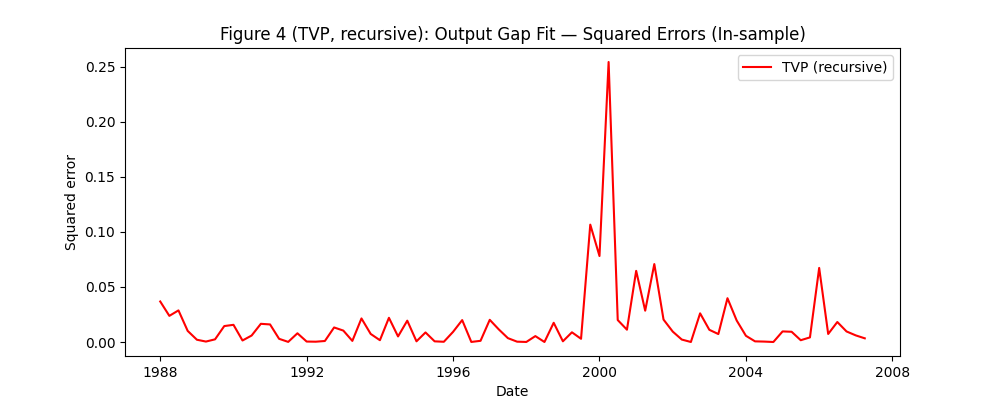

In [329]:
# Figure 4 (TVP): Output gap squared errors
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ins.index.to_timestamp(), ins["se_y_tvp"], color="red", linewidth=1.5, label="TVP (recursive)")
ax.set_title("Figure 4 (TVP, recursive): Output Gap Fit — Squared Errors (In-sample)")
ax.set_xlabel("Date")
ax.set_ylabel("Squared error")
ax.grid(False)
ax.legend()
plt.show()

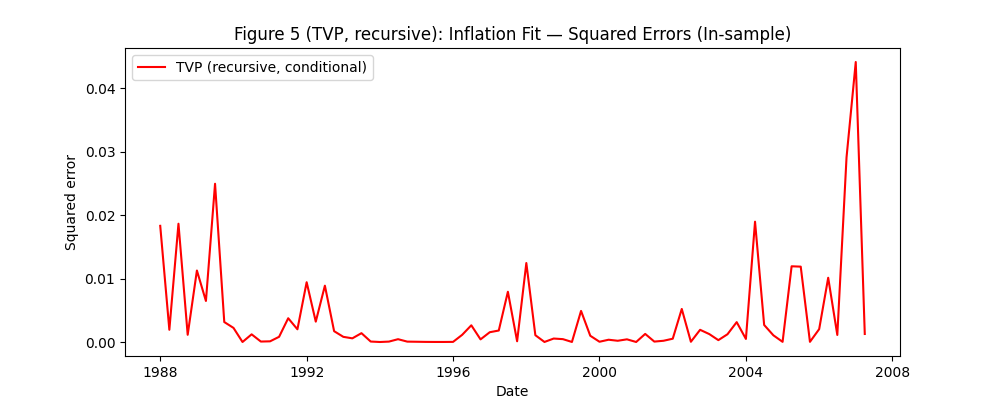

In [330]:
# Figure 5 (TVP): Inflation squared errors (conditional on realized y_t by construction)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ins.index.to_timestamp(), ins["se_pi_tvp"], color="red", linewidth=1.5, label="TVP (recursive, conditional)")
ax.set_title("Figure 5 (TVP, recursive): Inflation Fit — Squared Errors (In-sample)")
ax.set_xlabel("Date")
ax.set_ylabel("Squared error")
ax.grid(False)
ax.legend()
plt.show()

In [ ]:
# --- TVP: Out-of-sample actual vs predicted (2007Q3+) ---

# Posterior mean predictions (already computed earlier; recompute here if needed)
mu_y_mean  = idata_y.posterior["mu"].mean(("chain", "draw")).values   # (T,)
mu_pi_mean = idata_pi.posterior["mu"].mean(("chain", "draw")).values  # (T,)

fit_tvp = pd.DataFrame(
    {
        "y_hat": mu_y_mean,
        "pi_hat": mu_pi_mean,
        "y": Y_y,
        "pi": Y_pi,
    },
    index=idx_tvp,
).sort_index()

# Optional: credible bands for mu (e.g., 5–95%)
mu_y_draws = (
    idata_y.posterior["mu"]
    .stack(sample=("chain", "draw"))
    .transpose("time", "sample")
    .values
)  # (T, S)

mu_pi_draws = (
    idata_pi.posterior["mu"]
    .stack(sample=("chain", "draw"))
    .transpose("time", "sample")
    .values
)  # (T, S)

fit_tvp["y_hat_p05"] = np.quantile(mu_y_draws, 0.05, axis=1)
fit_tvp["y_hat_p95"] = np.quantile(mu_y_draws, 0.95, axis=1)
fit_tvp["pi_hat_p05"] = np.quantile(mu_pi_draws, 0.05, axis=1)
fit_tvp["pi_hat_p95"] = np.quantile(mu_pi_draws, 0.95, axis=1)

# --- Out-of-sample slice ---
tvp_oos = fit_tvp.loc["2007Q3":].copy()

# Errors + metrics
tvp_oos["err_y_tvp"] = tvp_oos["y"] - tvp_oos["y_hat"]
tvp_oos["err_pi_tvp"] = tvp_oos["pi"] - tvp_oos["pi_hat"]
tvp_oos["se_y_tvp"] = tvp_oos["err_y_tvp"] ** 2
tvp_oos["se_pi_tvp"] = tvp_oos["err_pi_tvp"] ** 2

mse_y = float(tvp_oos["se_y_tvp"].mean())
rmse_y = mse_y**0.5
mse_pi = float(tvp_oos["se_pi_tvp"].mean())
rmse_pi = mse_pi**0.5

print(f"TVP OOS (from 2007Q3) | y:  MSE={mse_y:.4f}, RMSE={rmse_y:.4f}, n={len(tvp_oos)}")
print(f"TVP OOS (from 2007Q3) | pi: MSE={mse_pi:.4f}, RMSE={rmse_pi:.4f}, n={len(tvp_oos)}")

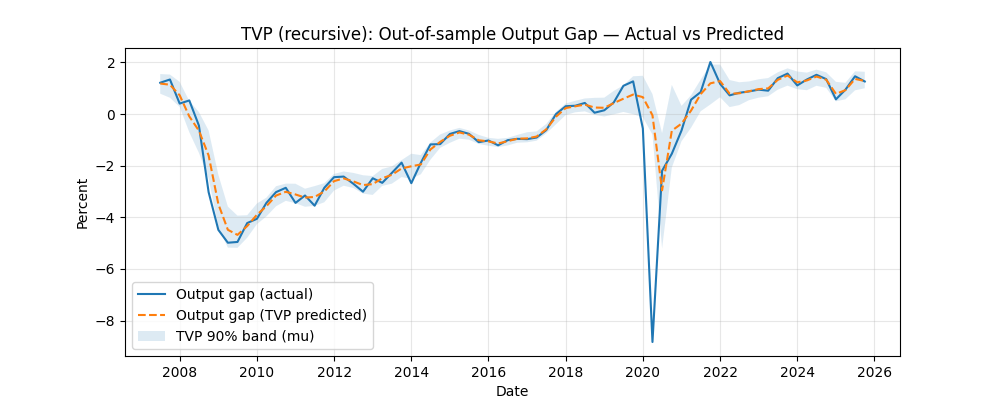

In [332]:
# --- Plot: Output gap actual vs predicted ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tvp_oos.index.to_timestamp(), tvp_oos["y"], label="Output gap (actual)")
ax.plot(tvp_oos.index.to_timestamp(), tvp_oos["y_hat"], "--", label="Output gap (TVP predicted)")

# credible band (optional)
ax.fill_between(
    tvp_oos.index.to_timestamp(),
    tvp_oos["y_hat_p05"],
    tvp_oos["y_hat_p95"],
    alpha=0.15,
    label="TVP 90% band (mu)",
)

ax.set_title("TVP (recursive): Out-of-sample Output Gap — Actual vs Predicted")
ax.set_xlabel("Date")
ax.set_ylabel("Percent")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

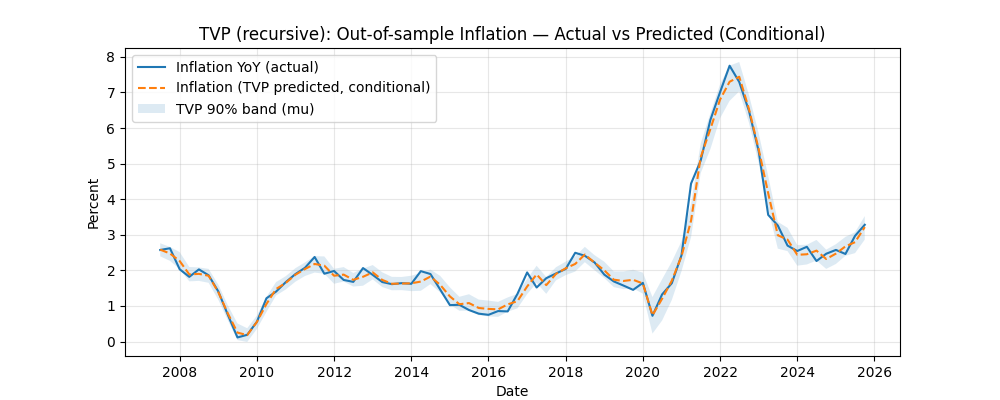

In [333]:
# --- Plot: Inflation actual vs predicted (conditional on realized y_t by construction) ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tvp_oos.index.to_timestamp(), tvp_oos["pi"], label="Inflation YoY (actual)")
ax.plot(tvp_oos.index.to_timestamp(), tvp_oos["pi_hat"], "--", label="Inflation (TVP predicted, conditional)")

# credible band (optional)
ax.fill_between(
    tvp_oos.index.to_timestamp(),
    tvp_oos["pi_hat_p05"],
    tvp_oos["pi_hat_p95"],
    alpha=0.15,
    label="TVP 90% band (mu)",
)

ax.set_title("TVP (recursive): Out-of-sample Inflation — Actual vs Predicted (Conditional)")
ax.set_xlabel("Date")
ax.set_ylabel("Percent")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

--------

# References

1. The pandas development team. pandas-dev/pandas: Pandas [Computer software]. https://doi.org/10.5281/zenodo.3509134

2. Sunder, N. (2025). fedfred: A Python client for the Federal Reserve Economic Database (FRED) API (Version 3.0.0) [Computer software]. https://doi.org/10.5281/zenodo.17180397

3. Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., Fernández del Río, J., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C., & Oliphant, T. E. (2020). Array programming with NumPy. Nature, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

4. Skipper, S., & Josef, P. (2010). statsmodels: Econometric and statistical modeling with python. 9th Python in Science Conference

5. Python Software Foundation. (2025). Python (Version 3.13.7) [Computer software]. Python Software Foundation. https://www.python.org/

6. Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

7. Hinterlang, N., & Tänzer, A. (2021). Optimal monetary policy using reinforcement learning. Deutsche Bundesbank.

8. Sims, C. A. (1980). Macroeconomics and Reality. Econometrica.

9. Lütkepohl, H. (2005). New Introduction to Multiple Time Series Analysis. Springer.

10. Clements, M. P., & Hendry, D. F. (1998). *Forecasting Economic Time Series*. Cambridge University Press.

11. Stock, J. H., & Watson, M. W. (2007). Why has U.S. inflation become harder to forecast? *Journal of Money, Credit and Banking*, 39, 3–33.

12. Diebold, F. X., & Mariano, R. S. (1995). Comparing predictive accuracy. *Journal of Business & Economic Statistics*, 13(3), 253–263.

13. Cogley, T., & Sargent, T. J. (2005). Drifts and volatilities: Monetary policies and outcomes in the post WWII U.S. *Review of Economic Dynamics*.

14. Primiceri, G. E. (2005). Time varying structural vector autoregressions and monetary policy. *Review of Economic Studies*.
